# Library

In [67]:
# Ignore the warnings
import warnings
# warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

# System related and data input controls
import os

# Python path
import sys
base_folder = 'DataScience'
location_base = os.path.join(os.getcwd().split(base_folder)[0], base_folder)
location_module = [os.path.join(location_base, 'Module')] 
for each in location_module:
    if each not in sys.path:
        sys.path.append(each)

# Auto reload of library
%reload_ext autoreload
%autoreload 2

from import_KK import *
# DeviceStrategy_CPU()
DeviceStrategy_GPU()
from preprocessing_KK import *
from preprocessing_project_KK import *
from description_KK import *
from algorithm_machinelearning_KK import *
from algorithm_deeplearning_KK import *
from evaluation_KK import *
from visualization_KK import *


=========== GPU Strategy ===========
Detected GPUs:
 [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Only 1 GPU detected. Using single-GPU strategy.


======= GPU / CUDA / STATUS ========
Cuda Ready?        True
CUDA Version:      12.5.1
cuDNN Version:     9

TF Version:        2.20.0
Keras Version:     3.13.0
True
Torch Version:       2.8.0+cu128
Torch CUDA Version:  12.8
Torch cuDNN Version: 91002

Torch GPUs Available: 1
Use the GPU: NVIDIA GeForce RTX 4070 Laptop GPU



# Hyperparameters

In [12]:
# Data
FOLDER_GDM, FOLDER_GDS = get_google_drivelocation(gdrive='z', glocation=os.path.join('Research', 'SavedData', 'MDIS-OldAdult'))
FOLDER_LOCATION = FOLDER_GDM
FILENAME = 'master_nontime_return_KK.csv'
FILE_LOCATION = os.path.join(FOLDER_LOCATION, FILENAME)
LANGUAGE = 'kr'

# Preprocessing
Y_colname = 'return'
X_reverse = None
X_nullmax = None
X_nullmin = None
X_dummy = None
X_encoding = None
X_delYrelated = None
X_del = None

TEST_SIZE = 'Time'
YEAR_VAL, YEAR_TEST = 1, 1 # Execute when TEST_SIZE = 'Time'
RANDOM_STATE = 123
CLASS_STAT = True
## 'RandomUnderSampler' <<< 'TomekLinks' << 'CondensedNearestNeighbour' < 'OneSidedSelection'
## 'SMOTE' <<< 'SMOTETomek' << 'BorderlineSMOTE' < 'ADASYN', 'auto'
# SAMPLING_METHOD = 'ADASYN'
SAMPLING_METHOD = 'auto'
## 'minority', 'not majority', 'not minority', 'all', 'auto'
SAMPLING_STRATEGY = 'auto'    # 'minority', 'not majority', 'not minority', 'all', 'auto'
SCALER = 'minmax'
LABEL_LIST = ['Negative', 'Positive']

# Model
## Common
TUNE_TRIALS_ML = 30
TUNE_TRIALS_DL = 10
CV_SPLITS = 5
## ML
TUNE_METRIC = 'F1-score' # Default('auto'): 'F1-score', 'RMSE' - 접두사 없어도 자동으로 validation set 기준으로 판단TUNE_METRIC = 'auto'
## DL
tf.random.set_seed(123)
NODE_MLP = [128, 256, 128, 64, 32, 10]
NODE_CNN = [32, 64, 128]
VALIDATION_SPLIT = 0.2
if VALIDATION_SPLIT != None:
    VALIDATION_DATA = None
BATCH_SIZE = 64
EPOCHS = 1000
VERBOSE = 0
TUNE_METRIC_DL = 'val_F1-score' # 'AUC', 'Accuracy', 'F1-score', 'loss', 'val_AUC', 'val_Accuracy', 'val_F1-score', 'val_loss'
## Final + XAI
METRIC_FINAL = "F1-score"
SHAP = True
INTERACTION = True
INTERACTION_SAMPLES = 2000
# FEATURE_PERTURBATION = 'tree_path_dependent'    # 'tree_path_dependent', 'interventional'
X_TOP_DISPLAY = 50

# Save
SAVE_NAME_PREDSTATTR = 'DescriptiveStatistics_BinaryPredTrain.csv'
SAVE_NAME_PREDSTATTE = 'DescriptiveStatistics_BinaryPredTest.csv'
SAVE_NAME_ML = 'Performance_ML'
SAVE_NAME_DL = 'Performance_DL'
SAVE_NAME_PERFORMANCE = 'Performance.csv'

# Data Preprocessing

In [28]:
# 데이터로딩
df_raw = pd.read_csv(os.path.join('.', 'Data', FILENAME), encoding='cp949')

In [45]:
### Date and Author: 20260412, Kyungwon Kim ### 
def preprocessing_CO2(df_raw, X_delete=None,
                          Y_colname='IPV',
                          test_size=0.2, year_val=1, year_test=1,
                          cv_splits=5,
                          class_stat=True,
                          sampling_method=None, sampling_strategy='auto',
                          scaler='minmax', random_state=123,
                          label_list=['0','1'], language='kr'):
    start = time.time()
    df = df_raw.copy()
    print('\nPreprocessing for Data Prepare...')
    print('Initial Shape: ', df.shape)

    sec = time.time()-start
    print(str(datetime.timedelta(seconds=sec)).split(".")[0])

    start = time.time()
    print('\nPreprocessing for Learning...')
    # 불필요 변수 삭제
    print('\nDeleting Non-meaning Variables...')
    col_delete = []
    if X_delete != None:
        col_delete.extend(X_delete)
    df = df[[col for col in df.columns if col not in col_delete]]
    print('Shape of Data: ', df.shape)
    X_delete = [col for col in df_raw.columns if col not in list(df.columns)]

    # 종속변수 및 독립변수 설정
    df[Y_colname] = df[Y_colname].apply(lambda x: 1 if x>0 else 0)
    print(df[Y_colname].value_counts())
    X_colname = [x for x in df.columns if x != Y_colname]

    # # 수동 처리
    # mapping_dict = {
    #     'Q3b~Q4': 1,
    #     'Q1': 2,
    #     'Q2': 3,
    #     'Q3a': 4
    # }
    # df['vintage_bucket'] = df['vintage_bucket'].map(mapping_dict)

    # 결측치 처리
    print('\nPreprocessing NAN...')
    df_X = null_filling(df[[i for i in df.columns if i != Y_colname]])
    df = pd.concat([df[Y_colname], df_X], axis=1)
    X_colname = [x for x in df.columns if x != Y_colname]
    # X_colname = [x for x in df.columns if x != 'date']

    # Train, Test 분리
    if test_size == 'Time':
        ## 데이터에 존재하는 고유 연도를 추출 및 정렬
        unique_years = sorted(df['date'].dropna().apply(lambda x: x[:4]).unique())
        ## 외부 파라미터(year_test, year_val)로 기준 연도 동적 계산
        test_threshold = unique_years[-year_test]
        val_threshold = unique_years[-(year_test + year_val)]
        display(unique_years, test_threshold, val_threshold)
        print(f'\n[OOT Split] Dynamic Year Cutoff (using "{'date'}")')
        print(f'   - Train : ~ {int(val_threshold) - 1}')
        print(f'   - Val   : {int(val_threshold)} ~ {int(test_threshold) - 1}')
        print(f'   - Test  : {int(test_threshold)} ~')
        ## Train과 Val은 함께 묶어서 모델(샘플링)에 넘겨줌
        train_val_mask = df['date'] < test_threshold
        test_mask = df['date'] >= test_threshold
        X_train = df[train_val_mask][X_colname]
        Y_train = df[train_val_mask][[Y_colname]]
        X_test = df[test_mask][X_colname]
        Y_test = df[test_mask][[Y_colname]]
    elif isinstance(test_size, float) and test_size < 1:
        X_train, X_test, Y_train, Y_test = train_test_split(df[X_colname], df[[Y_colname]],
                                                            test_size=test_size, random_state=random_state)
    else:
        X_train, X_test, Y_train, Y_test = datasplit_timeseries_size(df, Y_colname, 
                                                                     test_size=test_size, shape_show=False)
    print(X_train.shape, Y_train.shape)
    print(X_test.shape, Y_test.shape)
    print('Data Split!')
 
    # 기술통계
    if class_stat:
        plot_classfrequency(df, Y_colname, label_list=label_list)
        comparisonstat_origin = table_ratiobyclass(df, Y_colname, label_list=label_list, sorting=True, save=True)
        display(comparisonstat_origin)
    print('Comparison Statistics of X by Y class!')
        
    # 샘플링
    if sampling_method != None:
        if sampling_method in ['RandomUnderSampler', 'TomekLinks', 'CondensedNearestNeighbour', 'OneSidedSelection']:
            print('Undersampling...')
            sampler, X_train, Y_train = undersampling(X_train, Y_train,
                                                      method=sampling_method, strategy=sampling_strategy,
                                                      random_state=random_state)   
        elif sampling_method in ['SMOTE', 'SMOTETomek', 'BorderlineSMOTE', 'ADASYN']:
            print('Oversampling...')
            sampler, X_train, Y_train = oversampling(X_train, Y_train,
                                                      method=sampling_method, strategy=sampling_strategy,
                                                      random_state=random_state)  
        elif sampling_method == 'auto':
            if df[Y_colname].value_counts().sort_values(ascending=False).index[0] == 0:
                print('Undersampling...')
                sampling_method = 'RandomUnderSampler'
                sampler, X_train, Y_train = undersampling(X_train, Y_train,
                                                      method=sampling_method, strategy=sampling_strategy,
                                                      random_state=random_state)   
            else:
                print('Oversampling...')
                sampling_method = 'ADASYN'
                sampler, X_train, Y_train = oversampling(X_train, Y_train,
                                                      method=sampling_method, strategy=sampling_strategy,
                                                      random_state=random_state)   
        ## Old: Over에선 Test는 건드리지 않는게 좀더 현실적
        X_test, Y_test = sampler.fit_resample(X_test, Y_test) 

    # Optuna 튜닝용 OOT 인덱스 추출
    cv_splits = cv_splits
    if test_size == 'Time':
        if isinstance(X_train, pd.DataFrame):
            train_idx = np.where(X_train['date'] < val_threshold)[0].tolist()
            val_idx = np.where(X_train['date'] >= val_threshold)[0].tolist()
        else:
            year_idx = X_colname.index('date')
            train_idx = np.where(X_train[:, year_idx] < val_threshold)[0].tolist()
            val_idx = np.where(X_train[:, year_idx] >= val_threshold)[0].tolist()
        cv_splits = (train_idx, val_idx)
        print(f"   ▷ [Generated CV Tuple] Train Index: {len(train_idx)}, Val Index: {len(val_idx)}")

# ==========================================================
    # [수정된 부분] 스케일링 및 모델 학습 전 'date' 변수 제거 및 동기화
    # ==========================================================
    # 1. date 변수를 X_colname에서 완전히 제거
    X_colname = [col for col in X_colname if col != 'date']

    # 2. 데이터 구조 강제 정렬 (고스트 컬럼 차단)
    if isinstance(X_train, pd.DataFrame):
        # 존재하는 컬럼만 추출하여 순서와 개수 완벽 동기화
        valid_cols = [col for col in X_colname if col in X_train.columns]
        X_train = X_train[valid_cols]
        X_test = X_test[valid_cols]
        X_colname = valid_cols # 최종 동기화
    else:
        # Numpy Array인 경우, X_colname 길이만큼 앞에서 자름
        X_train = X_train[:, :len(X_colname)]
        X_test = X_test[:, :len(X_colname)]
    # ==========================================================
    
    # 스케일링
    print('\nPreprocessing of Scaling...')
    scaler_dict = {}
    
    # 샘플링(SMOTE 등) 후 데이터가 DataFrame 혹은 Numpy Array일 수 있으므로 포맷 통일
    X_train_np = X_train.values if isinstance(X_train, pd.DataFrame) else X_train
    X_test_np = X_test.values if isinstance(X_test, pd.DataFrame) else X_test
    
    # 결과를 담을 빈 배열 생성
    X_train_scaled = np.zeros((X_train_np.shape[0], len(X_colname)), dtype=float)
    X_test_scaled = np.zeros((X_test_np.shape[0], len(X_colname)), dtype=float)
    
    for i, col in enumerate(X_colname):
        from sklearn.preprocessing import MinMaxScaler, StandardScaler
        # 조건에 맞는 스케일러 할당 (향후 확장을 위해)
        s = MinMaxScaler() if scaler == 'minmax' else StandardScaler()
        
        # 각 변수별로 2D 배열 추출
        train_col = X_train_np[:, i].reshape(-1, 1)
        test_col = X_test_np[:, i].reshape(-1, 1)
        
        # 변수별 스케일링 및 스케일러 객체를 딕셔너리에 저장
        X_train_scaled[:, i] = s.fit_transform(train_col).flatten()
        X_test_scaled[:, i] = s.transform(test_col).flatten()
        scaler_dict[col] = s
        
    X_train = X_train_scaled
    X_test = X_test_scaled

    print(X_train.shape, Y_train.shape, X_train.min(), X_train.max())
    print(X_test.shape, Y_test.shape, X_test.min(), X_test.max())   
    
    print('Complete!')
    sec = time.time()-start
    print(str(datetime.timedelta(seconds=sec)).split(".")[0])
    
    # 반환값 마지막에 scaler_dict 추가
    return X_train, X_test, Y_train, Y_test, df, X_colname, scaler_dict, cv_splits

In [46]:
# 전처리
X_train, X_test, Y_train, Y_test, df_prep, X_colname, scaler, CV_SPLITS = preprocessing_CO2(
    df_raw, 
    X_delete=X_del,
    Y_colname=Y_colname,
    test_size=TEST_SIZE,
    year_val=YEAR_VAL, year_test=YEAR_TEST,
    cv_splits=CV_SPLITS,
    class_stat=not CLASS_STAT, 
    sampling_method=SAMPLING_METHOD,
    sampling_strategy=SAMPLING_STRATEGY,
    scaler=SCALER,
    label_list=LABEL_LIST,
    language=LANGUAGE,
)


Preprocessing for Data Prepare...
Initial Shape:  (2035, 85)
0:00:00

Preprocessing for Learning...

Deleting Non-meaning Variables...
Shape of Data:  (2035, 85)
return
0    1236
1     799
Name: count, dtype: int64

Preprocessing NAN...
Column Deleting...
These  0.0 %( 0 ) columns are containing more than  50.0 % null values!: []

These  2 columns are containing just 1 unique value!: ['FV_KAU15', 'FV_KAU16']

Row Deleting...

Filling Null Values...


0it [00:00, ?it/s]


Shape of Data:  (2035, 82)
Complete of fillna!


['2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']

'2026'

'2025'


[OOT Split] Dynamic Year Cutoff (using "date")
   - Train : ~ 2024
   - Val   : 2025 ~ 2025
   - Test  : 2026 ~
(1963, 82) (1963, 1)
(72, 82) (72, 1)
Data Split!
Comparison Statistics of X by Y class!
Undersampling...
(1963, 82) (1963, 1)
Ratio of Origin Y:  return
0         1208
1          755
Name: count, dtype: int64
(1510, 82) (1510, 1)
Ratio of Sampling Y:  return
0         755
1         755
Name: count, dtype: int64
   ▷ [Generated CV Tuple] Train Index: 1324, Val Index: 186

Preprocessing of Scaling...
(1510, 81) (1510, 1) 0.0 1.0000000000000004
(56, 81) (56, 1) 0.0 2.41063287226644
Complete!
0:00:00


# Modeling

## Machine Learning

In [ ]:
# # Setting
# algorithm_list = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']
# TUNE_TRIALS = None
# # TUNE_TRIALS = 10

# # ML 실행
# results_ML, scores_ML = modeling_ML(
#     algos=algorithm_list,
#     X_train=X_train, Y_train=Y_train, X_test=X_test, Y_test=Y_test,
#     X_colname=X_colname,
#     params=None, # 특정 알고리즘
#     tune_trials=TUNE_TRIALS_ML, # 최적화 여부
#     cv_splits=CV_SPLITS,
#     tune_metric=TUNE_METRIC,
#     shap=not SHAP, 
#     X_selected=None, # shap에서만 작동
#     interaction=not INTERACTION,
#     interaction_samples=INTERACTION_SAMPLES, 
#     X_top_display=X_TOP_DISPLAY, 
#     label_list=LABEL_LIST,
# )

▶ Detected Task Type: [ classification ] (Target: binary)

   Running Machine Learning Algorithm: Logistic Regression (classification)
Learning...:  2026-05-17 22:49:06.991274


  0%|          | 0/30 [00:00<?, ?it/s]

[Logistic Regression] Best Optuna Score (F1-score):  0.6188679245283019
[Logistic Regression] Best Tuning Parameters:  {'solver': 'saga', 'penalty': 'elasticnet', 'C': 0.12455784924890467, 'class_weight': 'balanced', 'max_iter': 1527, 'random_state': 123, 'l1_ratio': 0.7064893579223139}

Explanations...:  2026-05-17 22:49:48.793451
Explanations of Y:


,Features,Coef,Features,Coef
0,is_traded,0.7303,VIX_KR,-0.4941
1,ask_ratio_last_known,0.5477,USD,-0.2214
2,ask_ratio_last,0.5347,FV_KAU22,-0.1896
3,FV_KAU23,0.1135,ta_avg_dev_abs_window_max,-0.1351
4,FV_KAU20,0.0812,FV_KAU24,-0.1256
5,FV_KAU19,0.0501,CPI,-0.0769
6,BSI_E,0.0040,smp_window_days,-0.0641
7,IND_ORDER,0.0000,weather_window_days,-0.0641
8,BOND_BBB_lag1,0.0000,NaN,NaN
9,KRX_ENERGY_lag1,0.0000,NaN,NaN


Performance Evaluations...:  2026-05-17 22:49:48.800867
Performance: 


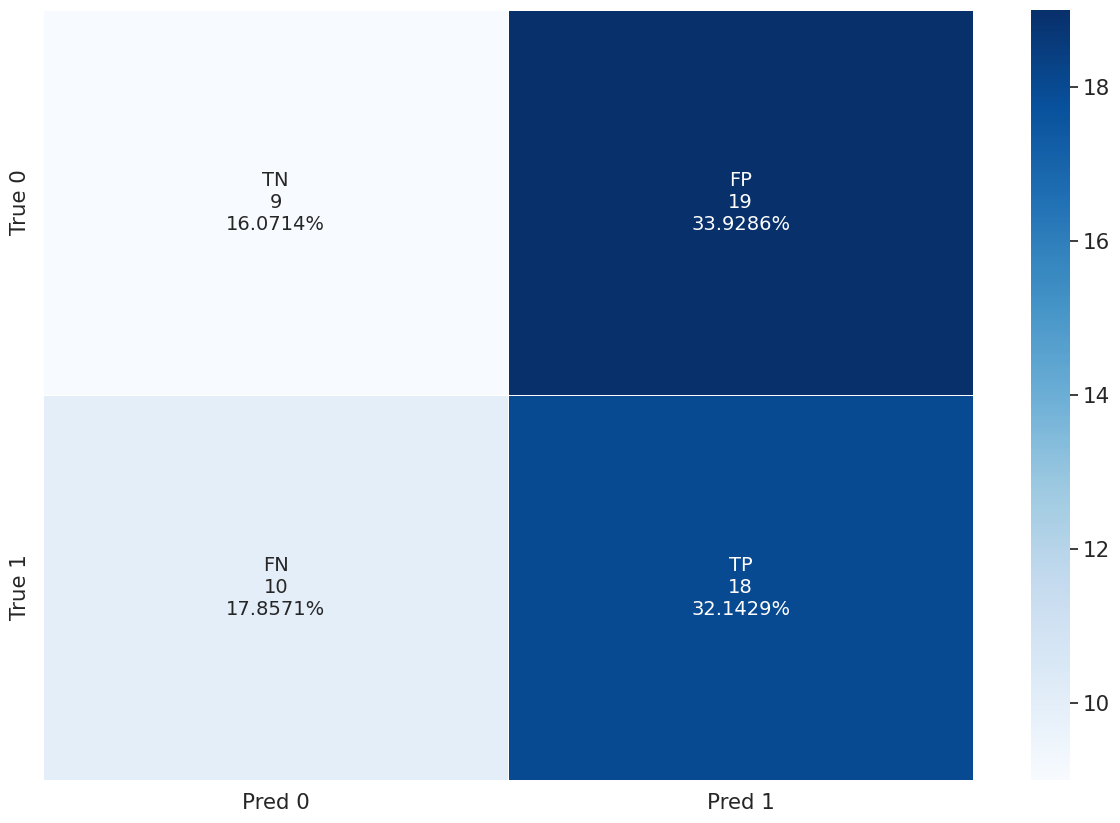

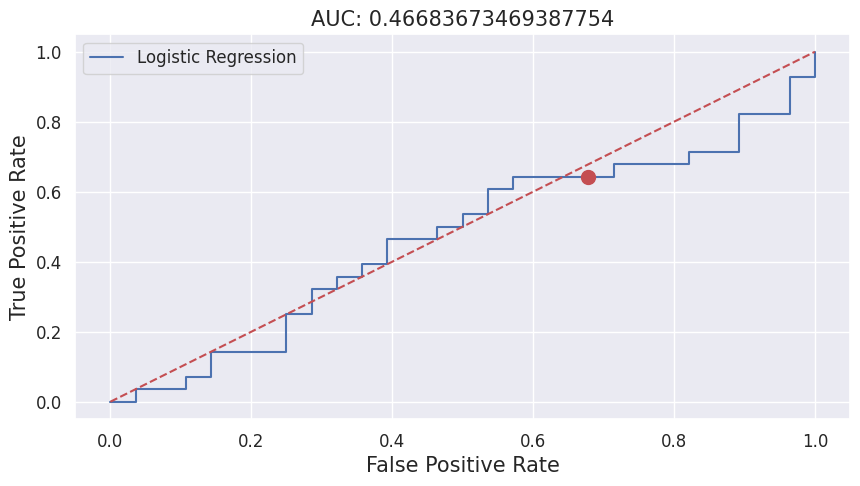

,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Logistic Regression,Train set,1510,528,374,381,227,0.5809,0.6993,0.4954,0.6346,0.5974,0.5974,0.6426
1,Logistic Regression,Validation(CV),186,82,3,100,1,0.4505,0.9880,0.0291,0.6189,0.4570,0.5085,0.5367
2,Logistic Regression,Test set,56,18,9,19,10,0.4865,0.6429,0.3214,0.5538,0.4821,0.4821,0.4668
3,Logistic Regression,Entire population,1566,546,383,400,237,0.5772,0.6973,0.4891,0.6316,0.5932,0.5932,0.6378


   [Save] Logistic Regression Checkpoint Saved:
     - Model : /mnt/c/DataScience/[DIVE]/Project/CO2XAI/Model/best_model_Logistic Regression_20260517_224949.pkl
     - Params: /mnt/c/DataScience/[DIVE]/Project/CO2XAI/Model/best_params_Logistic Regression_20260517_224949.json

   Running Machine Learning Algorithm: Random Forest (classification)
Learning...:  2026-05-17 22:49:49.204209


  0%|          | 0/30 [00:00<?, ?it/s]

[Random Forest] Best Optuna Score (F1-score):  0.5690376569037657
[Random Forest] Best Tuning Parameters:  {'n_estimators': 600, 'max_depth': 32, 'max_features': None, 'min_samples_split': 7, 'min_samples_leaf': 13, 'bootstrap': False, 'random_state': 123, 'n_jobs': -1, 'class_weight': 'balanced_subsample'}

Explanations...:  2026-05-17 22:50:51.127385
Explanations of Y:


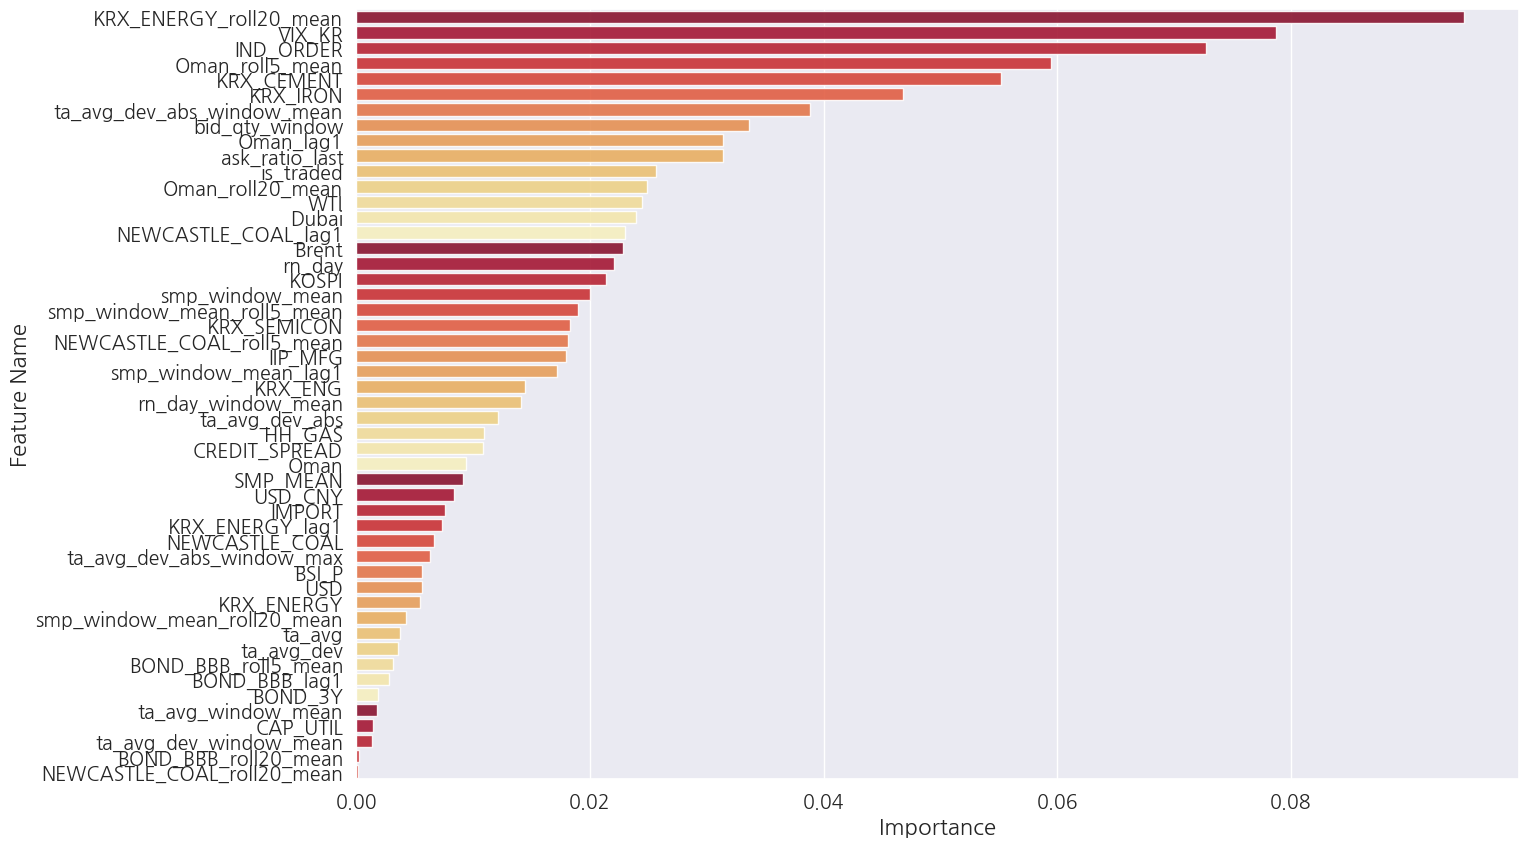

Performance Evaluations...:  2026-05-17 22:50:51.610620
Performance: 


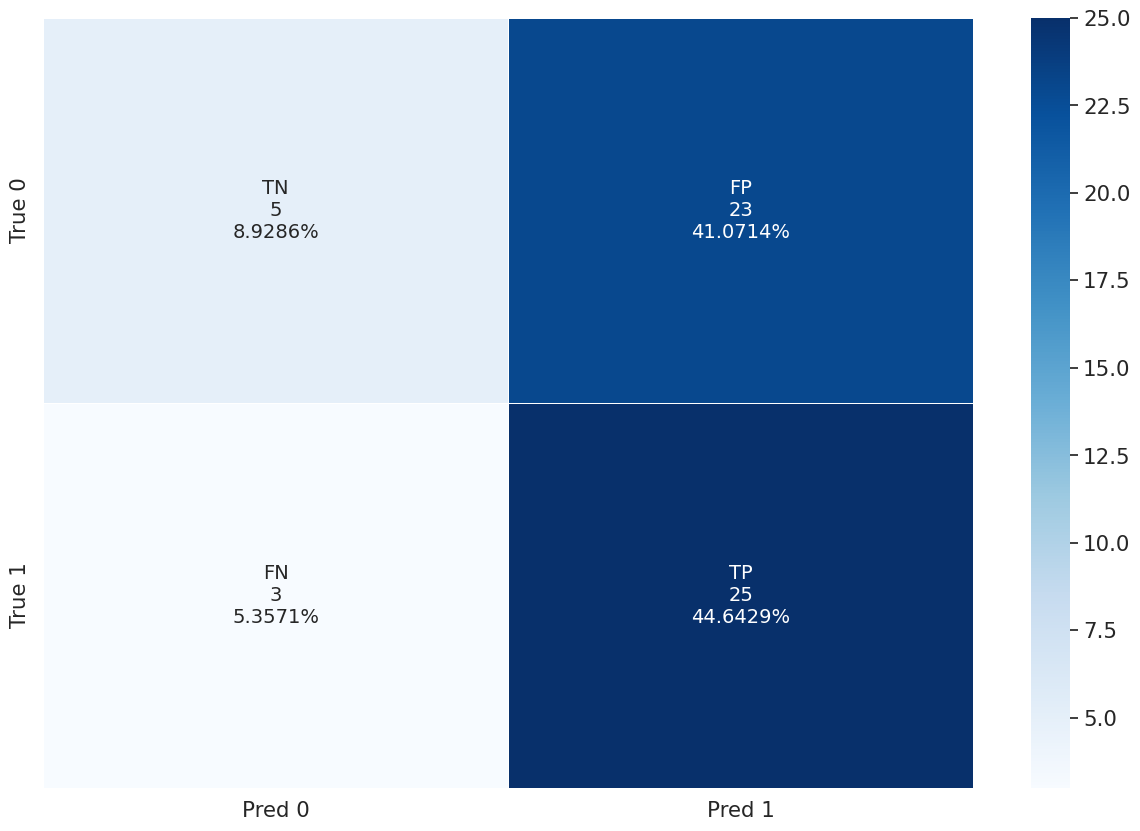

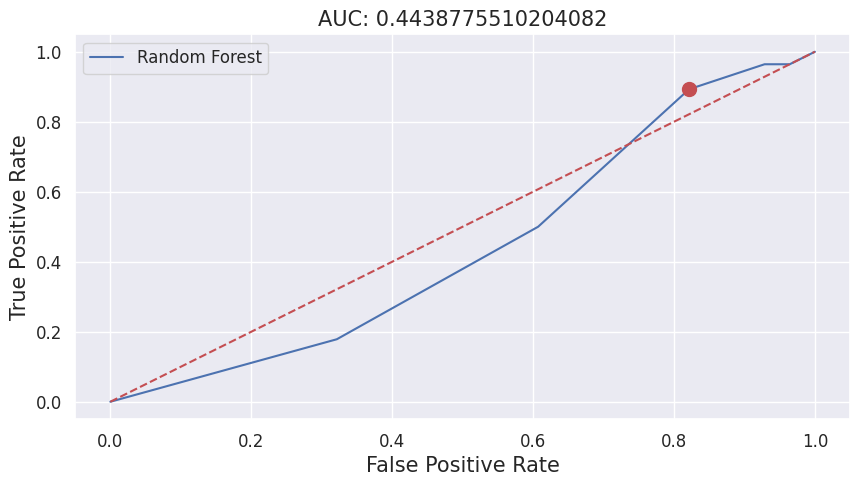

,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Random Forest,Train set,1510,588,631,124,167,0.8258,0.7788,0.8358,0.8016,0.8073,0.8073,0.8975
1,Random Forest,Validation(CV),186,68,15,88,15,0.4359,0.8193,0.1456,0.5690,0.4462,0.4825,0.5297
2,Random Forest,Test set,56,25,5,23,3,0.5208,0.8929,0.1786,0.6579,0.5357,0.5357,0.4439
3,Random Forest,Entire population,1566,613,636,147,170,0.8066,0.7829,0.8123,0.7946,0.7976,0.7976,0.8847


   [Save] Random Forest Checkpoint Saved:
     - Model : /mnt/c/DataScience/[DIVE]/Project/CO2XAI/Model/best_model_Random Forest_20260517_225054.pkl
     - Params: /mnt/c/DataScience/[DIVE]/Project/CO2XAI/Model/best_params_Random Forest_20260517_225054.json

   Running Machine Learning Algorithm: XGBoost (classification)
Learning...:  2026-05-17 22:50:54.259090


  0%|          | 0/30 [00:00<?, ?it/s]

[XGBoost] Best Optuna Score (F1-score):  0.6194029850746269
[XGBoost] Best Tuning Parameters:  {'n_estimators': 900, 'max_depth': 5, 'learning_rate': 0.0017090746117377853, 'subsample': 0.6950192265831139, 'colsample_bytree': 0.5952806671102233, 'min_child_weight': 1.3774343133181153, 'gamma': 3.9008139890092126, 'reg_alpha': 2.821403359937222e-07, 'reg_lambda': 0.08130918564909398, 'random_state': 123, 'n_jobs': -1, 'tree_method': 'hist', 'verbosity': 0, 'scale_pos_weight': 4.4466067967808325}

Explanations...:  2026-05-17 22:54:34.395844
Explanations of Y:


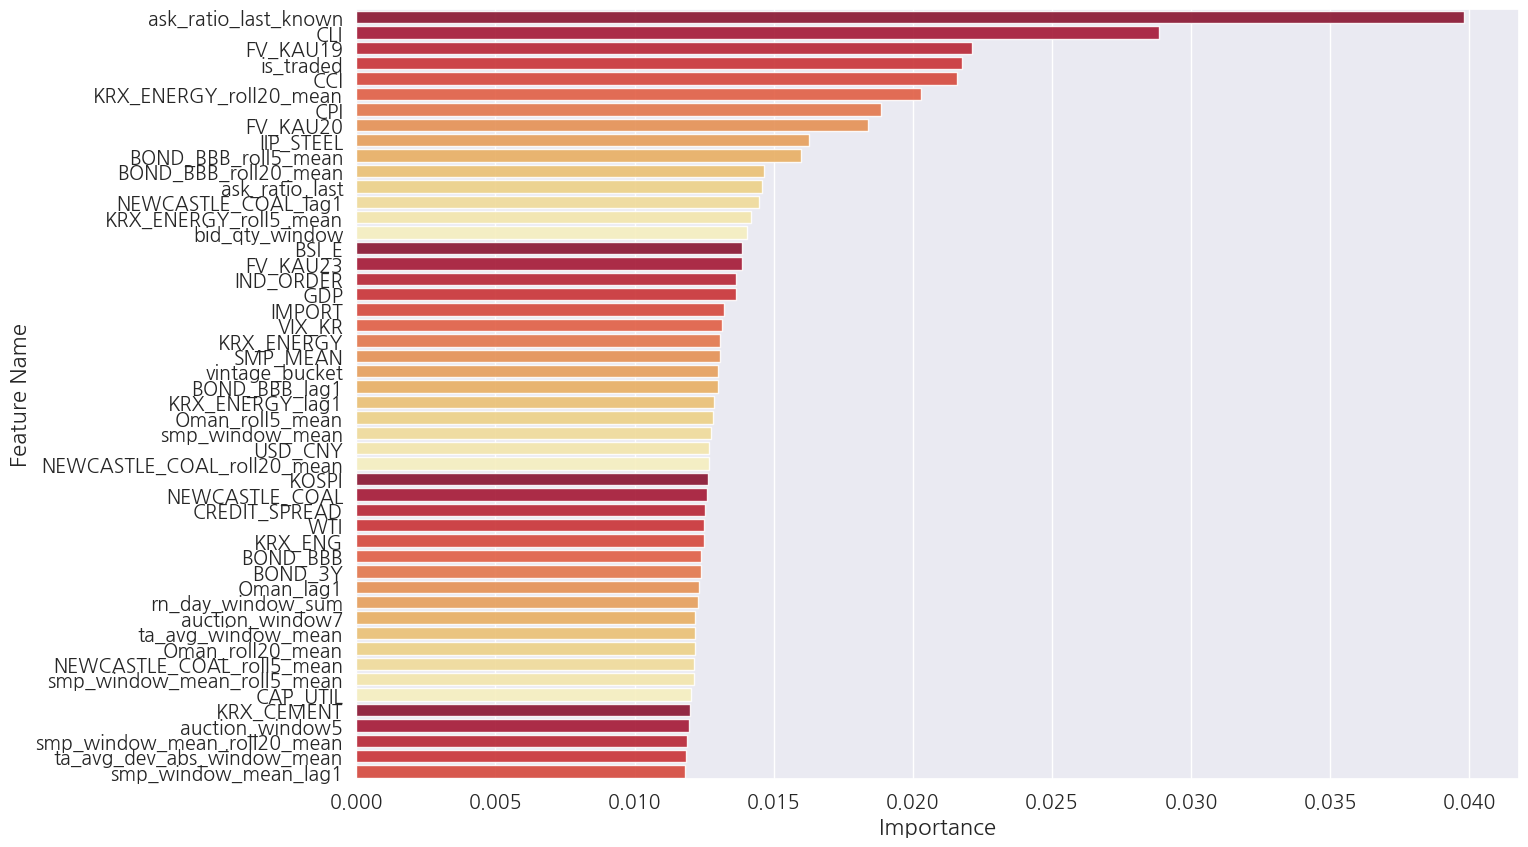

Performance Evaluations...:  2026-05-17 22:54:34.846034
Performance: 


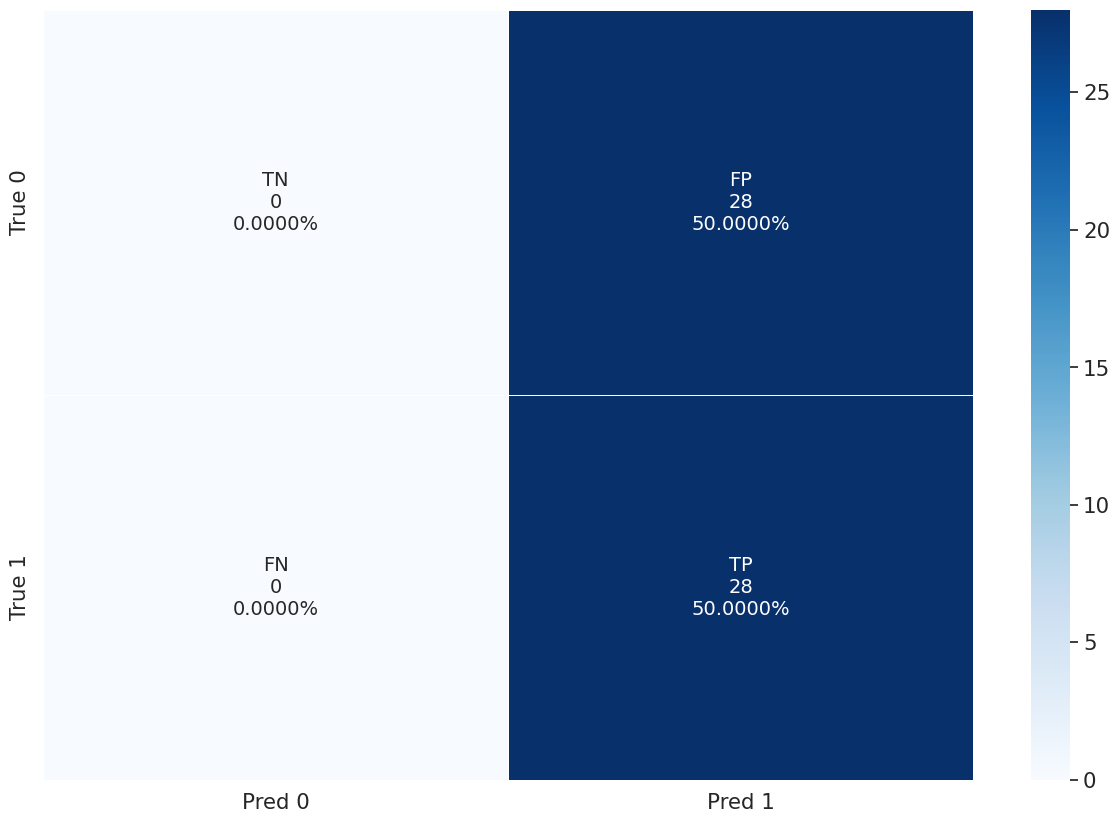

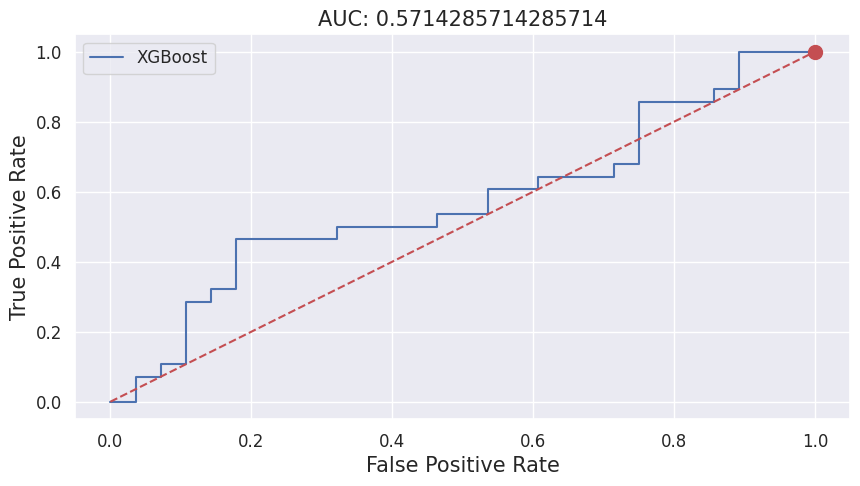

,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,XGBoost,Train set,1510,755,115,640,0,0.5412,1.0000,0.1523,0.7023,0.5762,0.5762,0.8628
1,XGBoost,Validation(CV),186,83,1,102,0,0.4486,1.0000,0.0097,0.6194,0.4516,0.5049,0.4893
2,XGBoost,Test set,56,28,0,28,0,0.5000,1.0000,0.0000,0.6667,0.5000,0.5000,0.5714
3,XGBoost,Entire population,1566,783,115,668,0,0.5396,1.0000,0.1469,0.7010,0.5734,0.5734,0.8486


   [Save] XGBoost Checkpoint Saved:
     - Model : /mnt/c/DataScience/[DIVE]/Project/CO2XAI/Model/best_model_XGBoost_20260517_225435.pkl
     - Params: /mnt/c/DataScience/[DIVE]/Project/CO2XAI/Model/best_params_XGBoost_20260517_225435.json

   Running Machine Learning Algorithm: LightGBM (classification)
Learning...:  2026-05-17 22:54:35.901275


  0%|          | 0/30 [00:00<?, ?it/s]

[LightGBM] Best Optuna Score (F1-score):  0.6212121212121212
[LightGBM] Best Tuning Parameters:  {'n_estimators': 300, 'learning_rate': 0.002117743719358478, 'num_leaves': 109, 'max_depth': 10, 'min_child_samples': 59, 'subsample': 0.8634443503369947, 'colsample_bytree': 0.8010043881827235, 'min_split_gain': 0.14618861481804227, 'extra_trees': True, 'reg_alpha': 0.005900603905849417, 'reg_lambda': 8.672448728672824, 'random_state': 123, 'n_jobs': -1, 'verbose': -1, 'class_weight': None}

Explanations...:  2026-05-17 22:58:23.514164
Explanations of Y:


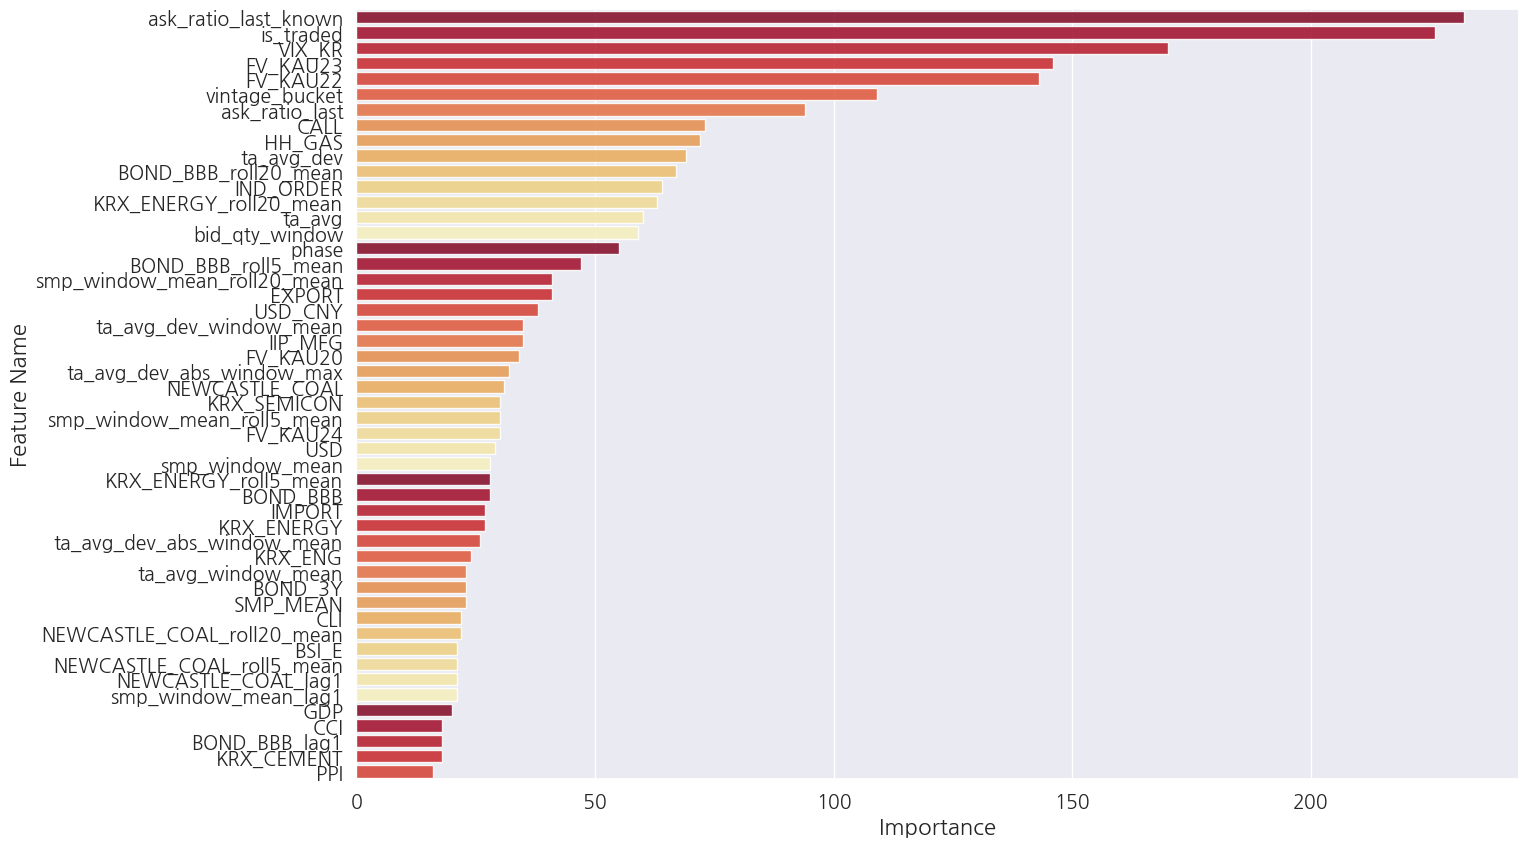

Performance Evaluations...:  2026-05-17 22:58:23.934783
Performance: 


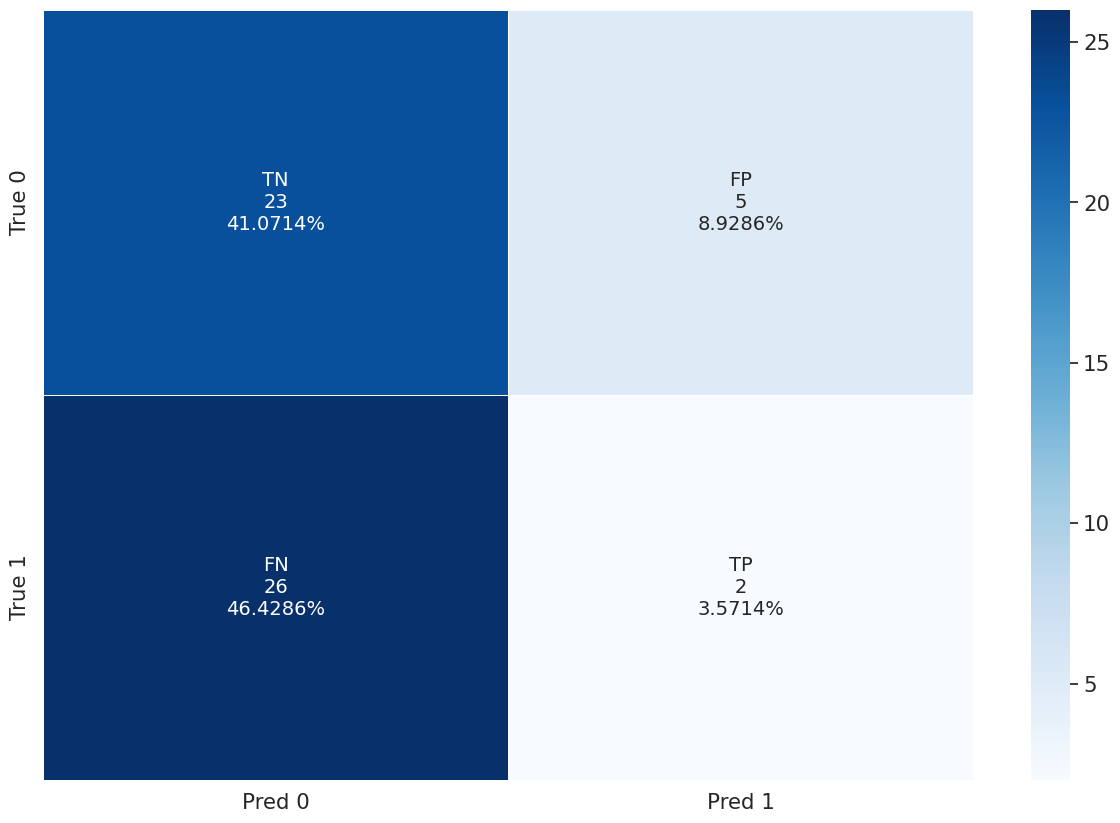

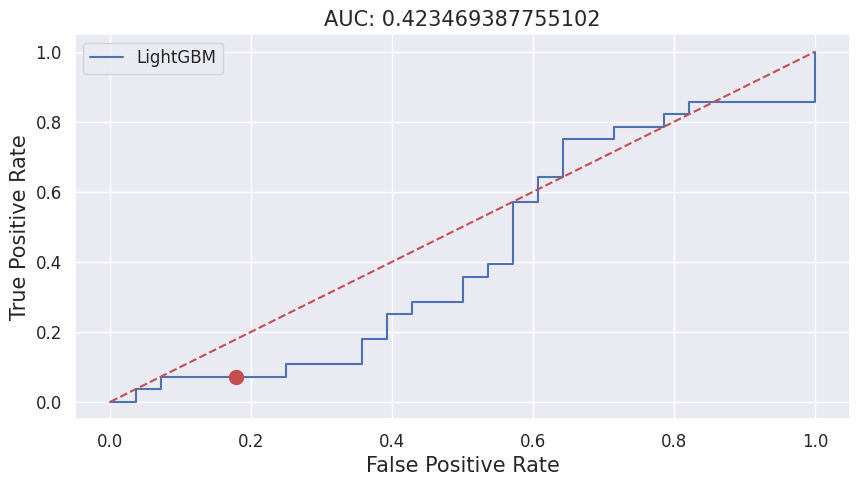

,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,LightGBM,Train set,1510,510,456,299,245,0.6304,0.6755,0.6040,0.6522,0.6397,0.6397,0.6954
1,LightGBM,Validation(CV),186,82,4,99,1,0.4530,0.9880,0.0388,0.6212,0.4624,0.5134,0.5144
2,LightGBM,Test set,56,2,23,5,26,0.2857,0.0714,0.8214,0.1143,0.4464,0.4464,0.4235
3,LightGBM,Entire population,1566,512,479,304,271,0.6275,0.6539,0.6117,0.6404,0.6328,0.6328,0.6885


   [Save] LightGBM Checkpoint Saved:
     - Model : /mnt/c/DataScience/[DIVE]/Project/CO2XAI/Model/best_model_LightGBM_20260517_225824.pkl
     - Params: /mnt/c/DataScience/[DIVE]/Project/CO2XAI/Model/best_params_LightGBM_20260517_225824.json

   Running Machine Learning Algorithm: CatBoost (classification)
Learning...:  2026-05-17 22:58:24.600323


  0%|          | 0/30 [00:00<?, ?it/s]

[CatBoost] Best Optuna Score (F1-score):  0.5844748858447488
[CatBoost] Best Tuning Parameters:  {'iterations': 700, 'depth': 6, 'learning_rate': 0.29346299061761194, 'l2_leaf_reg': 8.992320806455249, 'subsample': 0.576074245689042, 'grow_policy': 'Depthwise', 'random_state': 123, 'verbose': 0, 'allow_writing_files': False}

Explanations...:  2026-05-17 23:00:57.837842
Explanations of Y:


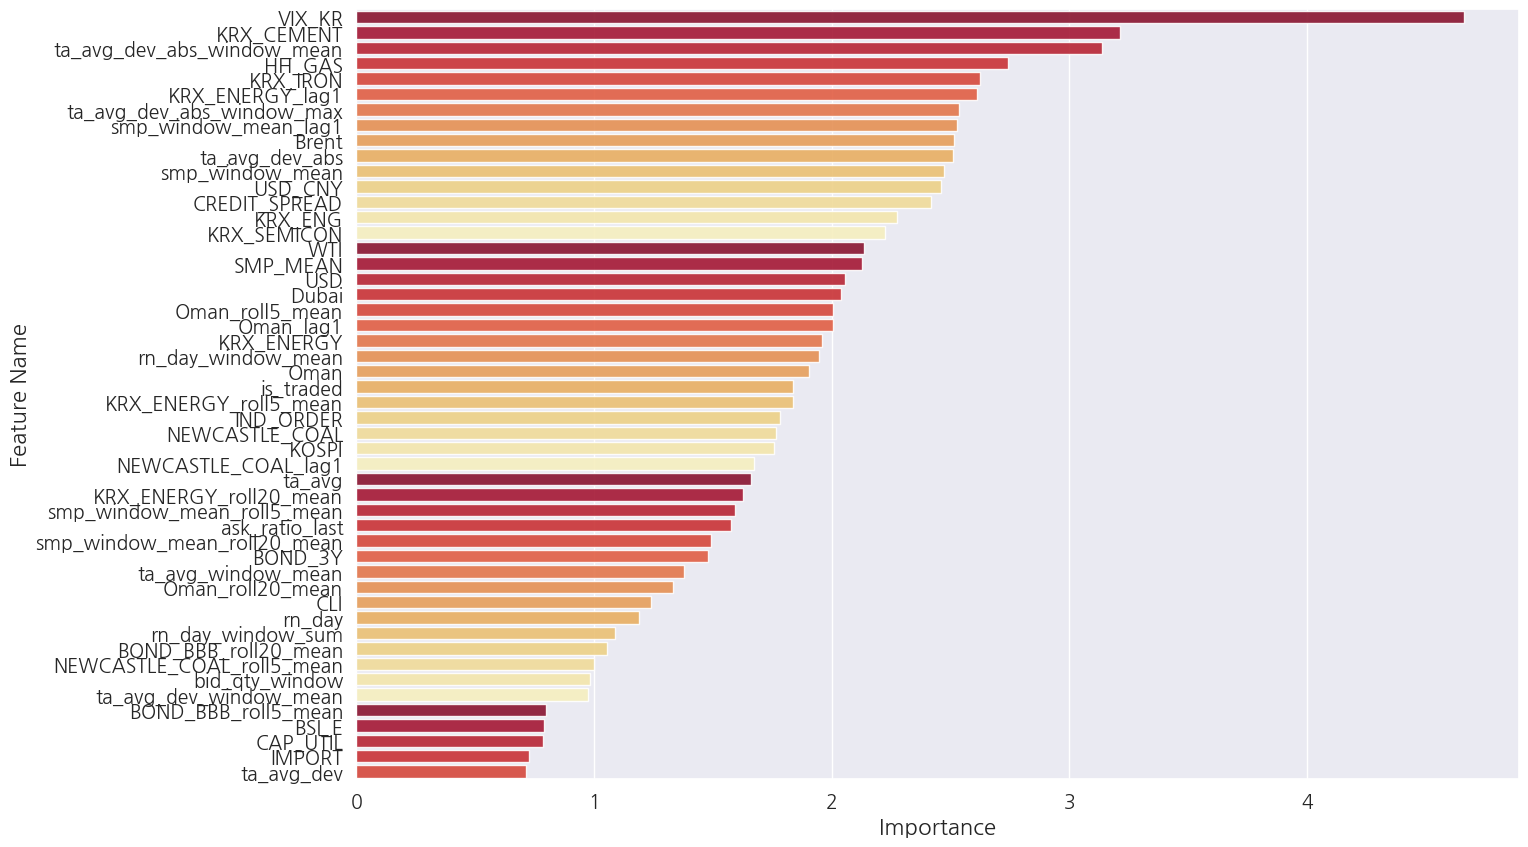

Performance Evaluations...:  2026-05-17 23:00:58.243851
Performance: 


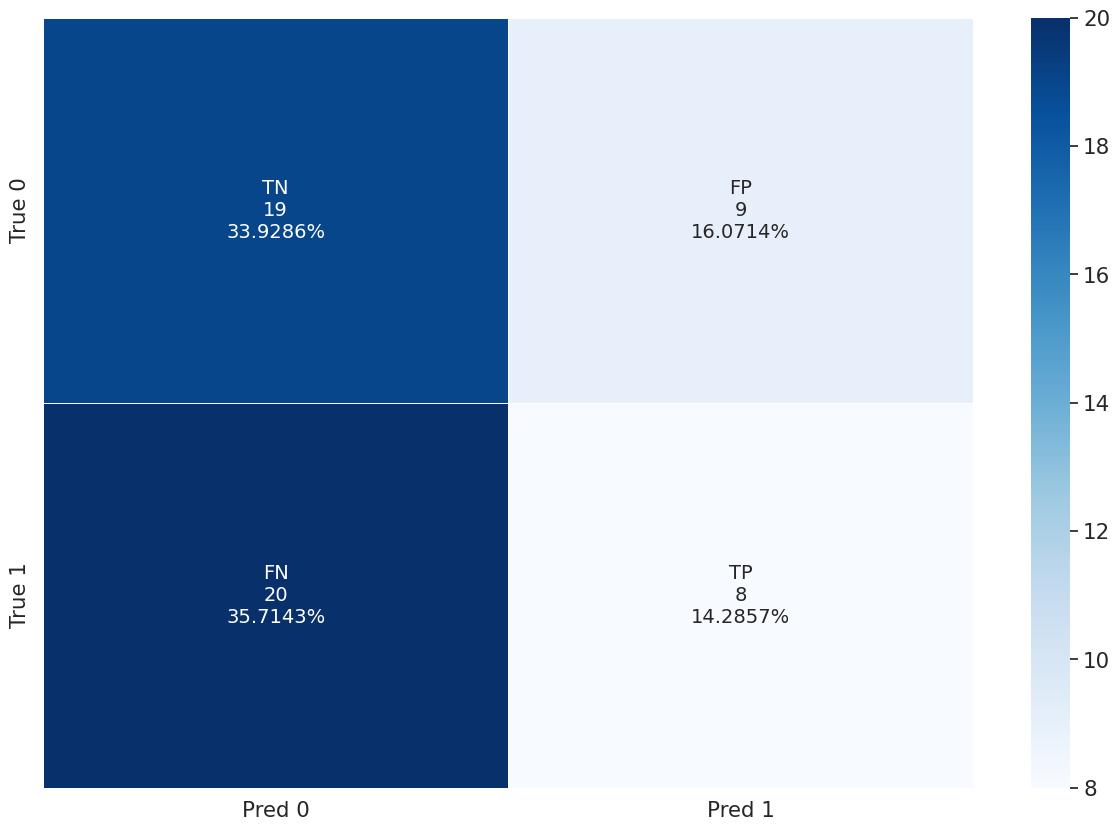

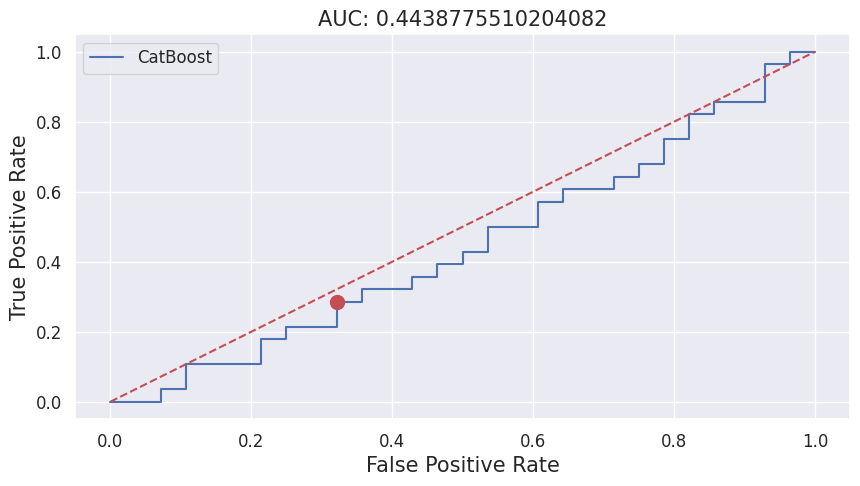

,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,CatBoost,Train set,1510,755,755,0,0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,CatBoost,Validation(CV),186,61,38,65,22,0.4706,0.7711,0.3010,0.5845,0.5108,0.5360,0.5217
2,CatBoost,Test set,56,8,19,9,20,0.4706,0.2857,0.6786,0.3556,0.4821,0.4821,0.4439
3,CatBoost,Entire population,1566,763,774,9,20,0.9883,0.9745,0.9885,0.9814,0.9815,0.9815,0.9991


   [Save] CatBoost Checkpoint Saved:
     - Model : /mnt/c/DataScience/[DIVE]/Project/CO2XAI/Model/best_model_CatBoost_20260517_230102.pkl
     - Params: /mnt/c/DataScience/[DIVE]/Project/CO2XAI/Model/best_params_CatBoost_20260517_230102.json

   Modeling Completed. Summary of Performance (classification)


,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Logistic Regression,Train set,1510,528,374,381,227,0.580858,0.699338,0.495364,0.634615,0.597351,0.597351,0.642586
4,Random Forest,Train set,1510,588,631,124,167,0.825843,0.778808,0.835762,0.801636,0.807285,0.807285,0.897508
8,XGBoost,Train set,1510,755,115,640,0,0.541219,1.000000,0.152318,0.702326,0.576159,0.576159,0.862803
12,LightGBM,Train set,1510,510,456,299,245,0.630408,0.675497,0.603974,0.652174,0.639735,0.639735,0.695370
16,CatBoost,Train set,1510,755,755,0,0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
1,Logistic Regression,Validation(CV),186,82,3,100,1,0.450549,0.987952,0.029126,0.618868,0.456989,0.508539,0.536671
5,Random Forest,Validation(CV),186,68,15,88,15,0.435897,0.819277,0.145631,0.569038,0.446237,0.482454,0.529711
9,XGBoost,Validation(CV),186,83,1,102,0,0.448649,1.000000,0.009709,0.619403,0.451613,0.504854,0.489297
13,LightGBM,Validation(CV),186,82,4,99,1,0.453039,0.987952,0.038835,0.621212,0.462366,0.513393,0.514446
17,CatBoost,Validation(CV),186,61,38,65,22,0.470588,0.771084,0.300971,0.584475,0.510753,0.536028,0.521698


,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
2,Logistic Regression,Test set,56,18,9,19,10,0.486486,0.642857,0.321429,0.553846,0.482143,0.482143,0.466837
6,Random Forest,Test set,56,25,5,23,3,0.520833,0.892857,0.178571,0.657895,0.535714,0.535714,0.443878
10,XGBoost,Test set,56,28,0,28,0,0.500000,1.000000,0.000000,0.666667,0.500000,0.500000,0.571429
14,LightGBM,Test set,56,2,23,5,26,0.285714,0.071429,0.821429,0.114286,0.446429,0.446429,0.423469
18,CatBoost,Test set,56,8,19,9,20,0.470588,0.285714,0.678571,0.355556,0.482143,0.482143,0.443878


,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
3,Logistic Regression,Entire population,1566,546,383,400,237,0.577167,0.697318,0.489144,0.631579,0.593231,0.593231,0.637795
7,Random Forest,Entire population,1566,613,636,147,170,0.806579,0.782886,0.812261,0.794556,0.797573,0.797573,0.884712
11,XGBoost,Entire population,1566,783,115,668,0,0.539628,1.000000,0.146871,0.700985,0.573436,0.573436,0.848637
15,LightGBM,Entire population,1566,512,479,304,271,0.627451,0.653895,0.611750,0.640400,0.632822,0.632822,0.688494
19,CatBoost,Entire population,1566,763,774,9,20,0.988342,0.974457,0.988506,0.981350,0.981481,0.981481,0.999083


test
Saved total performance to: /mnt/c/DataScience/[DIVE]/Project/CO2XAI/Result/Performance_ML(Trial30).csv
Saved total parameters to: /mnt/c/DataScience/[DIVE]/Project/CO2XAI/Result/Hyperparams_ML(Trial30).csv
Saved total results object to: /mnt/c/DataScience/[DIVE]/Project/CO2XAI/Model/Best_Result_ML(Trial30).pkl


In [47]:
# Setting
algorithm_list = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']

# ML 실행
results_ML, scores_ML = modeling_ML(
    algos=algorithm_list,
    X_train=X_train, Y_train=Y_train, X_test=X_test, Y_test=Y_test,
    X_colname=X_colname,
    params=None, # 특정 알고리즘
    tune_trials=TUNE_TRIALS_ML, # 최적화 여부
    cv_splits=CV_SPLITS,
    tune_metric=TUNE_METRIC,
    shap=not SHAP, 
    X_selected=None, # shap에서만 작동
    interaction=not INTERACTION,
    interaction_samples=INTERACTION_SAMPLES, 
    X_top_display=X_TOP_DISPLAY, 
    label_list=LABEL_LIST,
)

## Deep Learning

In [ ]:
# # Setting
# algorithm_list = ['MLP', 'CNN']
# TUNE_TRIALS = None
# # TUNE_TRIALS = 10

# # DL 실행
# results_DL, scores_DL = modeling_DL(
#     algos=algorithm_list,
#     X_train=X_train, Y_train=Y_train, X_test=X_test, Y_test=Y_test,
#     node_list=None, # 특정 알고리즘
#     validation_split=VALIDATION_SPLIT,
#     validation_data=VALIDATION_DATA,
#     tune_trials=TUNE_TRIALS, # 최적화 여부
#     cv_splits=CV_SPLITS,
#     tune_metric=TUNE_METRIC_DL,
#     epochs=EPOCHS-500,
#     batch_size=BATCH_SIZE,
#     earlystop_patient=None,
#     shap_display=False,
#     label_list=LABEL_LIST,
#     random_state=RANDOM_STATE,
# )

In [ ]:
# # Setting
# algorithm_list = ['MLP', 'CNN']
# # algorithm_list = ['CNN']

# # DL 실행
# results_DL, scores_DL = modeling_DL(
#     algos=algorithm_list,
#     X_train=X_train, Y_train=Y_train, X_test=X_test, Y_test=Y_test,
#     node_list=None, # 특정 알고리즘
#     validation_split=VALIDATION_SPLIT,
#     validation_data=VALIDATION_DATA,
#     tune_trials=TUNE_TRIALS_DL, # 최적화 여부
#     cv_splits=CV_SPLITS,
#     tune_metric=TUNE_METRIC_DL,
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     earlystop_patient=None,
#     shap_display=False,
#     label_list=LABEL_LIST,
#     random_state=RANDOM_STATE,
# )

# Performance Summary

In [48]:
# Algorithms Loaded
algo_names = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'MLP', 'CNN']
# algo_names = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']

# Result Summary
folder_location = os.path.join(os.getcwd(),'Result')
scores = prediction_summary(
    folder_location=folder_location, 
    algonames=algo_names,
    save_name=SAVE_NAME_PERFORMANCE,
)

### Performance Summary : 7 Algorithms ###

>>> [Train set] Performance Comparison


,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Logistic Regression,1510,528,374,381,227,0.5809,0.6993,0.4954,0.6346,0.5974,0.5974,0.6426
1,Random Forest,1510,588,631,124,167,0.8258,0.7788,0.8358,0.8016,0.8073,0.8073,0.8975
2,XGBoost,1510,755,115,640,0,0.5412,1.0000,0.1523,0.7023,0.5762,0.5762,0.8628
3,LightGBM,1510,510,456,299,245,0.6304,0.6755,0.6040,0.6522,0.6397,0.6397,0.6954
4,CatBoost,1510,755,755,0,0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,MLP,1510,755,0,755,0,0.5000,1.0000,0.0000,0.6667,0.5000,0.5000,0.4474
6,CNN,1510,412,392,363,343,0.5316,0.5457,0.5192,0.5386,0.5325,0.5325,0.5436



>>> [Validation(CV)] Performance Comparison


,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Logistic Regression,186,82,3,100,1,0.4505,0.9880,0.0291,0.6189,0.4570,0.5085,0.5367
1,Random Forest,186,68,15,88,15,0.4359,0.8193,0.1456,0.5690,0.4462,0.4825,0.5297
2,XGBoost,186,83,1,102,0,0.4486,1.0000,0.0097,0.6194,0.4516,0.5049,0.4893
3,LightGBM,186,82,4,99,1,0.4530,0.9880,0.0388,0.6212,0.4624,0.5134,0.5144
4,CatBoost,186,61,38,65,22,0.4706,0.7711,0.3010,0.5845,0.5108,0.5360,0.5217
5,MLP,186,83,0,103,0,0.4462,1.0000,0.0000,0.6171,0.4462,0.5000,0.5462
6,CNN,186,4,97,6,79,0.4000,0.0482,0.9417,0.0860,0.5430,0.4950,0.5049



>>> [Test set] Performance Comparison


,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Logistic Regression,56,18,9,19,10,0.4865,0.6429,0.3214,0.5538,0.4821,0.4821,0.4668
1,Random Forest,56,25,5,23,3,0.5208,0.8929,0.1786,0.6579,0.5357,0.5357,0.4439
2,XGBoost,56,28,0,28,0,0.5000,1.0000,0.0000,0.6667,0.5000,0.5000,0.5714
3,LightGBM,56,2,23,5,26,0.2857,0.0714,0.8214,0.1143,0.4464,0.4464,0.4235
4,CatBoost,56,8,19,9,20,0.4706,0.2857,0.6786,0.3556,0.4821,0.4821,0.4439
5,MLP,56,28,0,28,0,0.5000,1.0000,0.0000,0.6667,0.5000,0.5000,0.5593
6,CNN,56,3,27,1,25,0.7500,0.1071,0.9643,0.1875,0.5357,0.5357,0.4464



>>> [Entire population] Performance Comparison


,Algorithm,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,Logistic Regression,1566,546,383,400,237,0.5772,0.6973,0.4891,0.6316,0.5932,0.5932,0.6378
1,Random Forest,1566,613,636,147,170,0.8066,0.7829,0.8123,0.7946,0.7976,0.7976,0.8847
2,XGBoost,1566,783,115,668,0,0.5396,1.0000,0.1469,0.7010,0.5734,0.5734,0.8486
3,LightGBM,1566,512,479,304,271,0.6275,0.6539,0.6117,0.6404,0.6328,0.6328,0.6885
4,CatBoost,1566,763,774,9,20,0.9883,0.9745,0.9885,0.9814,0.9815,0.9815,0.9991
5,MLP,1566,783,0,783,0,0.5000,1.0000,0.0000,0.6667,0.5000,0.5000,0.4505
6,CNN,1566,415,419,364,368,0.5327,0.5300,0.5351,0.5314,0.5326,0.5326,0.5405


# Best Model Prediction

▶ Searching Directory: /mnt/c/DataScience/[DIVE]/Project/CO2XAI/Model
Loading Model: XGBoost
   - File: best_model_XGBoost_20260517_225435.pkl
   - Successfully Loaded.
Performance: 


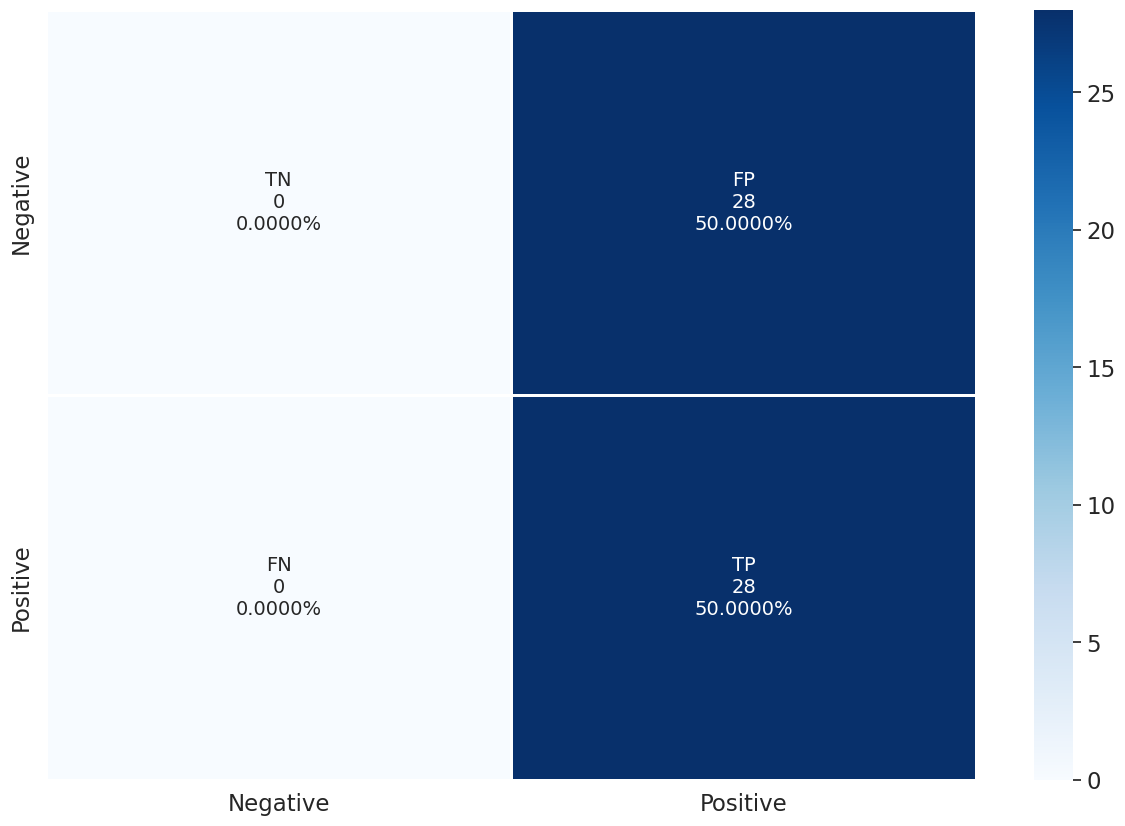

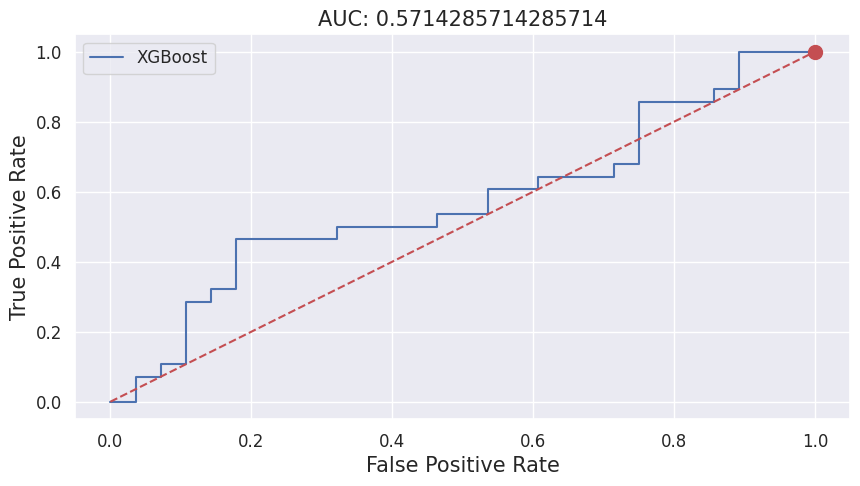

,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,XGBoost,Train set,1510,755,115,640,0,0.5412,1.0000,0.1523,0.7023,0.5762,0.5762,0.8628
1,XGBoost,Test set,56,28,0,28,0,0.5000,1.0000,0.0000,0.6667,0.5000,0.5000,0.5714
2,XGBoost,Entire population,1566,783,115,668,0,0.5396,1.0000,0.1469,0.7010,0.5734,0.5734,0.8486


In [49]:
# Model Loaded
best_scoreidx = np.argmax(scores[scores.Dataset=='Test set'][METRIC_FINAL])
best_algo = scores[scores.Dataset=='Test set'].iloc[best_scoreidx]['Algorithm']
# best_algo = 'XGBoost'
best_model, best_params = Loading_ModelBestParams(algo_name=best_algo)

# Performance Evaluation
Scores_Test = prediction_class(best_model, X_train, Y_train, X_test, Y_test,
                             LABEL_LIST=LABEL_LIST, ALGO_NAME=best_algo, keras=False)
display(Scores_Test)

# Explanation

▶ Detected Task Type: [ classification ] (Target: binary)

   Running Machine Learning Algorithm: XGBoost (classification)
Explanations...:  2026-05-17 23:01:02.499526
Total SHAP Calculation...: 2026-05-17 23:01:02.504222


 99%|===================| 1498/1510 [00:24<00:00]        

SHAP values saved to /mnt/c/DataScience/[DIVE]/Project/CO2XAI/Model/shap_values_XGBoost_20260517_230127.pkl
Train Dataset: 2026-05-17 23:01:27.107284
Total Explanation (Beeswarm + Importance Bar)...


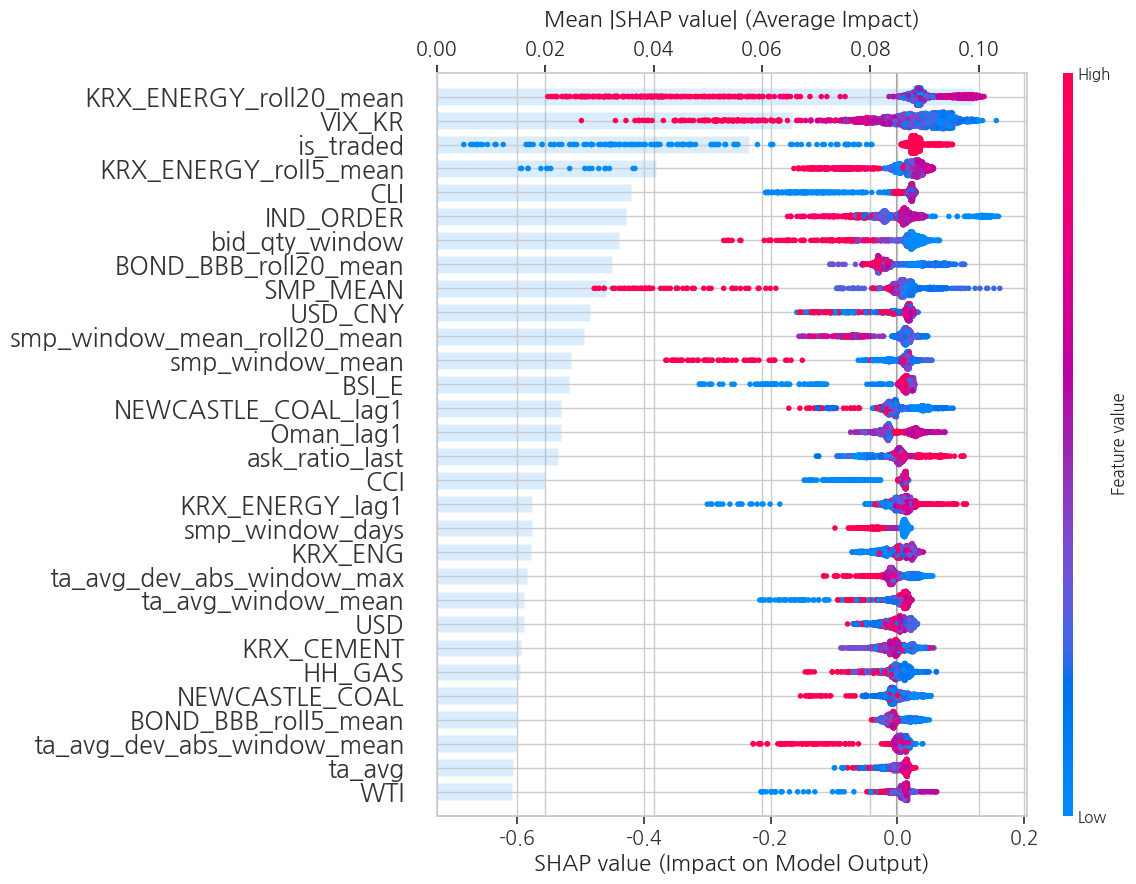

Test Dataset: 2026-05-17 23:01:27.702658
Total Explanation (Beeswarm + Importance Bar)...


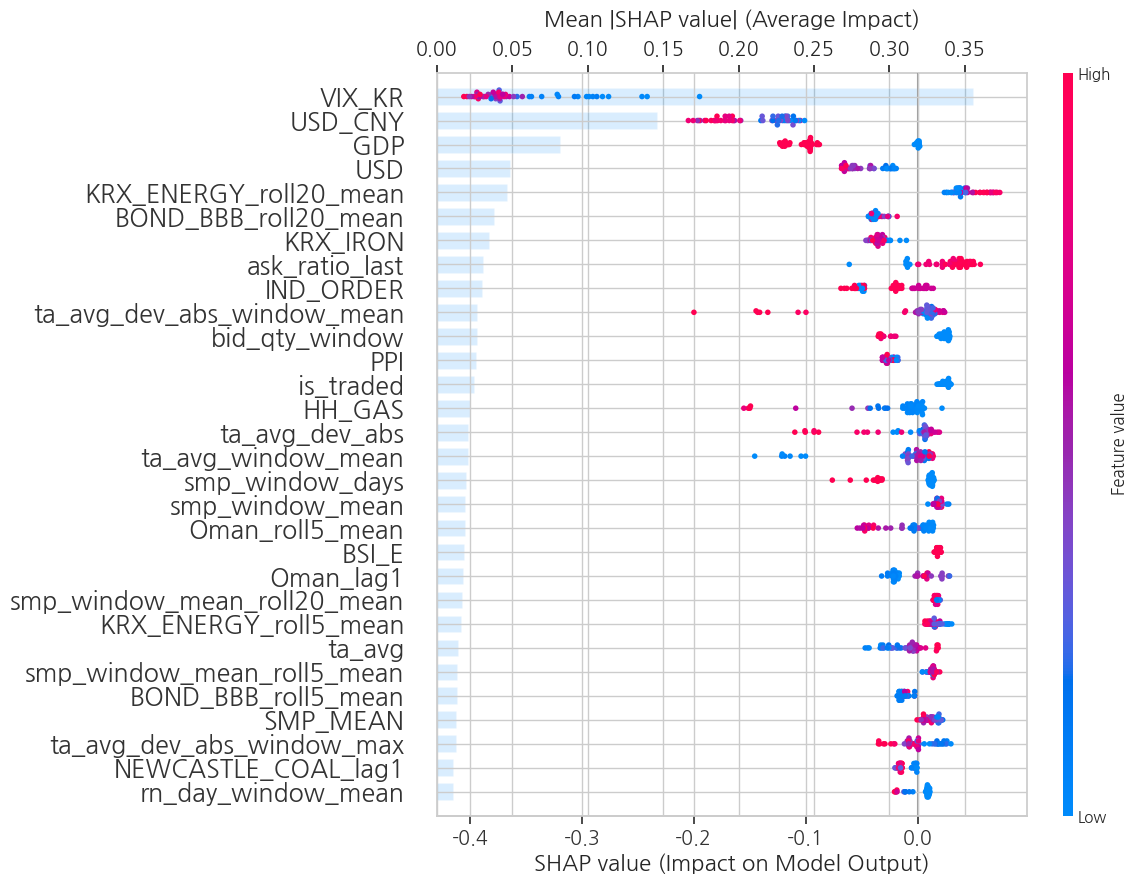

Test Dataset: 2026-05-17 23:01:28.210847
Feature Total Contribution...
Feature Contribution Direction...


100%|██████████| 81/81 [00:00<00:00, 146.41it/s]


,Feature,Importance,Contribution Range,Contribution (Correlation),Contribution (Linear Regression),Contbituion (Quantile Regression),Direction (Correlation),Direction (Linear Regression),Direction (Quantile Regression),Feature,Importance,Contribution Range,Contribution (Correlation),Contribution (Linear Regression),Contbituion (Quantile Regression),Direction (Correlation),Direction (Linear Regression),Direction (Quantile Regression)
0,KRX_ENERGY_roll20_mean,0.0463,0.0463,0.8109,0.0984,0.0545,+,+,+,VIX_KR,0.3555,0.3555,-0.7306,-0.1585,-0.0963,-,-,-
1,BOND_BBB_roll20_mean,0.0377,0.0377,0.2989,0.1174,0.1635,+,+,+,USD_CNY,0.1457,0.1457,-0.8426,-0.3221,-0.1622,-,-,-
2,ask_ratio_last,0.0306,0.0489,0.8434,0.0578,0.0000,+,+,+,GDP,0.0816,0.0981,-0.9754,-0.5348,-0.5348,-,-,-
3,IND_ORDER,0.0296,0.0428,0.1196,0.0198,0.0141,+,+,+,USD,0.0484,0.0484,-0.8765,-0.2784,-0.2069,-,-,-
4,ta_avg_window_mean,0.0203,0.0427,0.6308,0.1687,0.0559,+,+,+,KRX_IRON,0.0342,0.0342,-0.4516,-0.0249,-0.0541,-,-,-


,Feature,Importance,Contribution Range,Contribution (Correlation),Contribution (Linear Regression),Contbituion (Quantile Regression),Direction (Correlation),Direction (Linear Regression),Direction (Quantile Regression),Feature,Importance,Contribution Range,Contribution (Correlation),Contribution (Linear Regression),Contbituion (Quantile Regression),Direction (Correlation),Direction (Linear Regression),Direction (Quantile Regression)
0,ta_avg,0.0142,0.0258,0.9301,0.0959,0.0940,+,+,+,bid_qty_window,0.0262,0.0548,-0.9905,-0.2661,-0.2661,-,-,-
1,IIP_STEEL,0.0042,0.0083,0.9000,0.0332,-0.0063,+,+,-,smp_window_days,0.0195,0.0522,-0.9854,-0.1310,-0.1310,-,-,-
2,CREDIT_SPREAD,0.0052,0.0093,0.8956,0.0768,0.0596,+,+,+,GDP,0.0816,0.0981,-0.9754,-0.5348,-0.5348,-,-,-
3,ta_avg_dev,0.0044,0.0079,0.8565,0.0273,0.0231,+,+,+,IIP_MFG,0.0077,0.0098,-0.9643,-0.0306,0.0000,-,-,+
4,ask_ratio_last,0.0306,0.0489,0.8434,0.0578,0.0000,+,+,+,weather_window_days,0.0102,0.0270,-0.9435,-0.0633,-0.0633,-,-,-


Interaction SHAP Calculation...: 2026-05-17 23:01:28.857141
SHAP intervalues saved to /mnt/c/DataScience/[DIVE]/Project/CO2XAI/Model/shap_intervalues_XGBoost_20260517_230227.pkl
Test Dataset Interaction: 2026-05-17 23:02:27.382103
Feature Interactive Contribution...


Calculating Interactions: 100%|██████████| 81/81 [00:00<00:00, 978.12it/s]


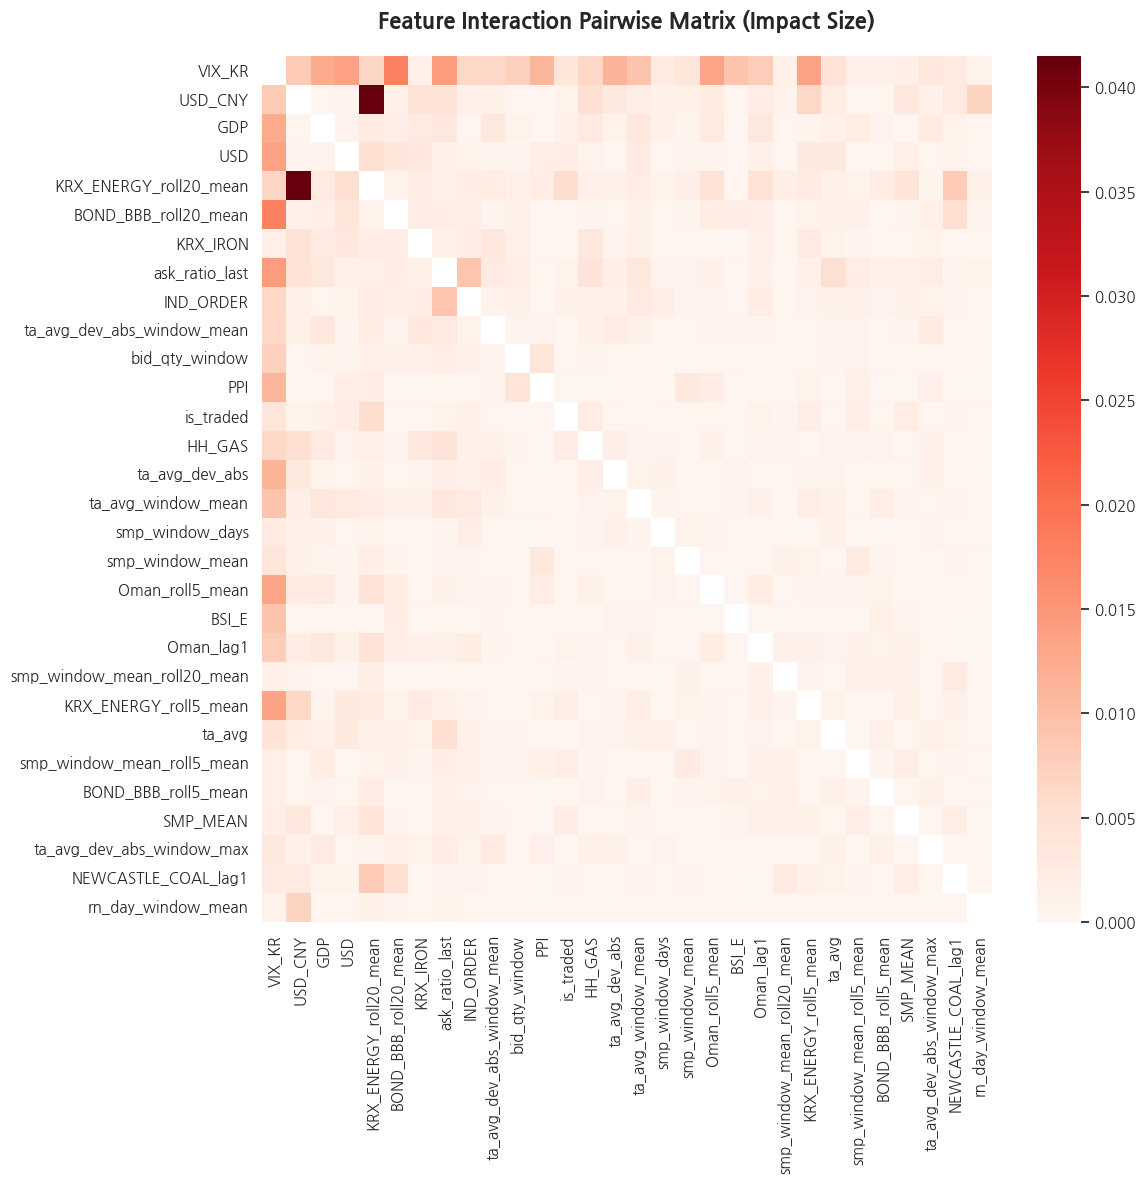

Calculating Correlations: 100%|██████████| 81/81 [00:00<00:00, 1204.86it/s]


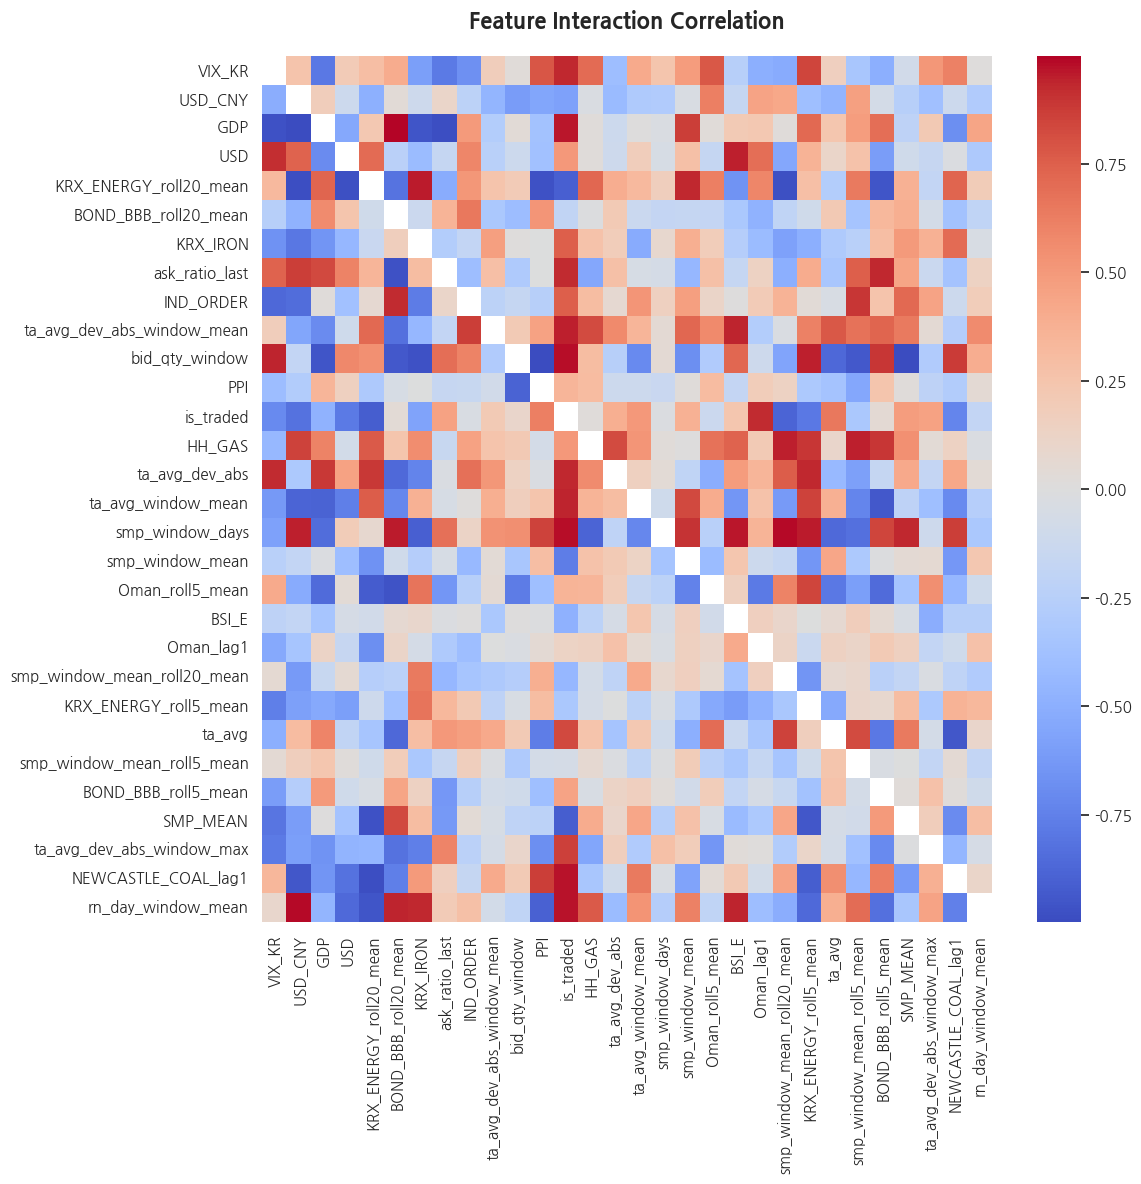


Test Dataset Sensitivity Analysis: 2026-05-17 23:02:28.599231
Sensitivity Analysis (ICE & PDP Plot) for Top 30 Features...


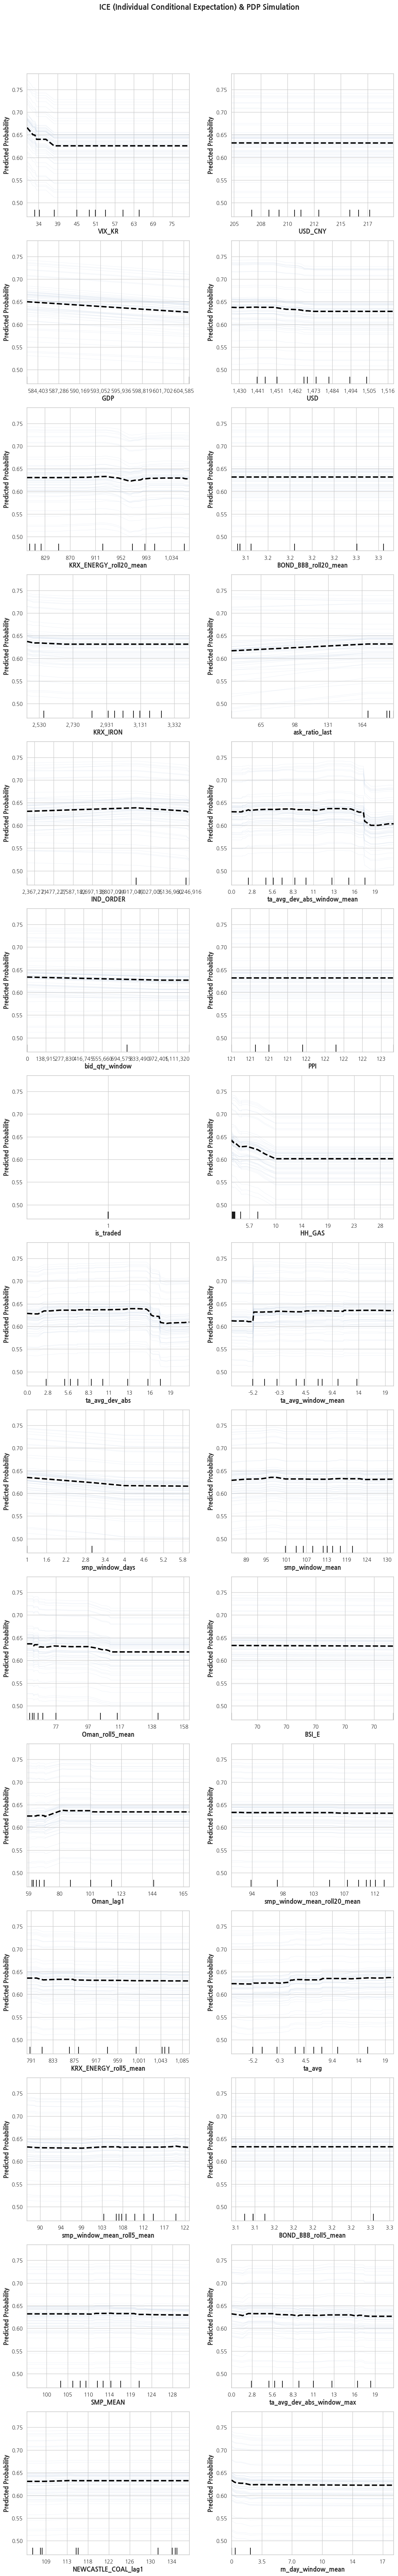

Train Dataset: 2026-05-17 23:02:33.133274
Individual Explanation(1 Decision Plot -> 1 Force Plot -> 1000 Force Plot)...
Visualizing random index: 1137


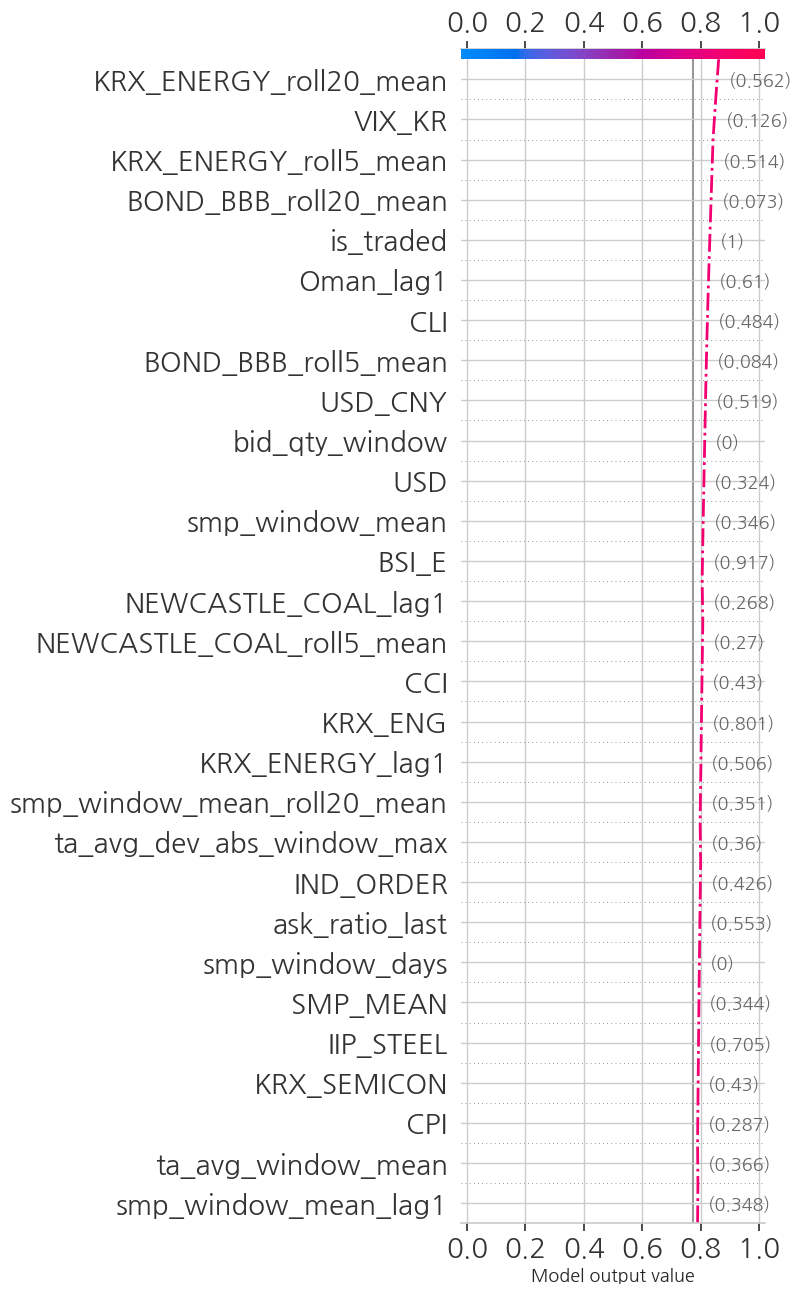

Test Dataset: 2026-05-17 23:02:33.492738
Individual Explanation(1 Decision Plot -> 1 Force Plot -> 1000 Force Plot)...
Visualizing random index: 38


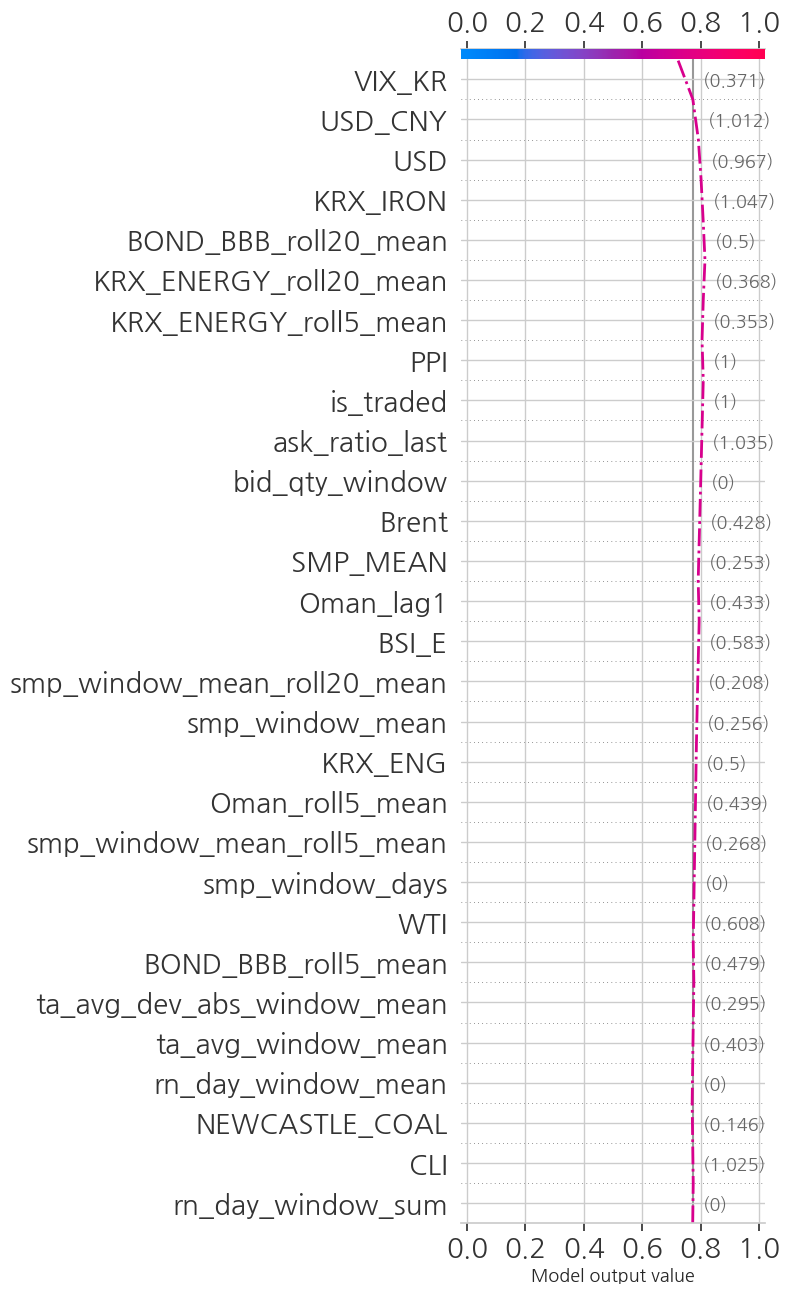

Performance Evaluations...:  2026-05-17 23:02:33.796709
Performance: 


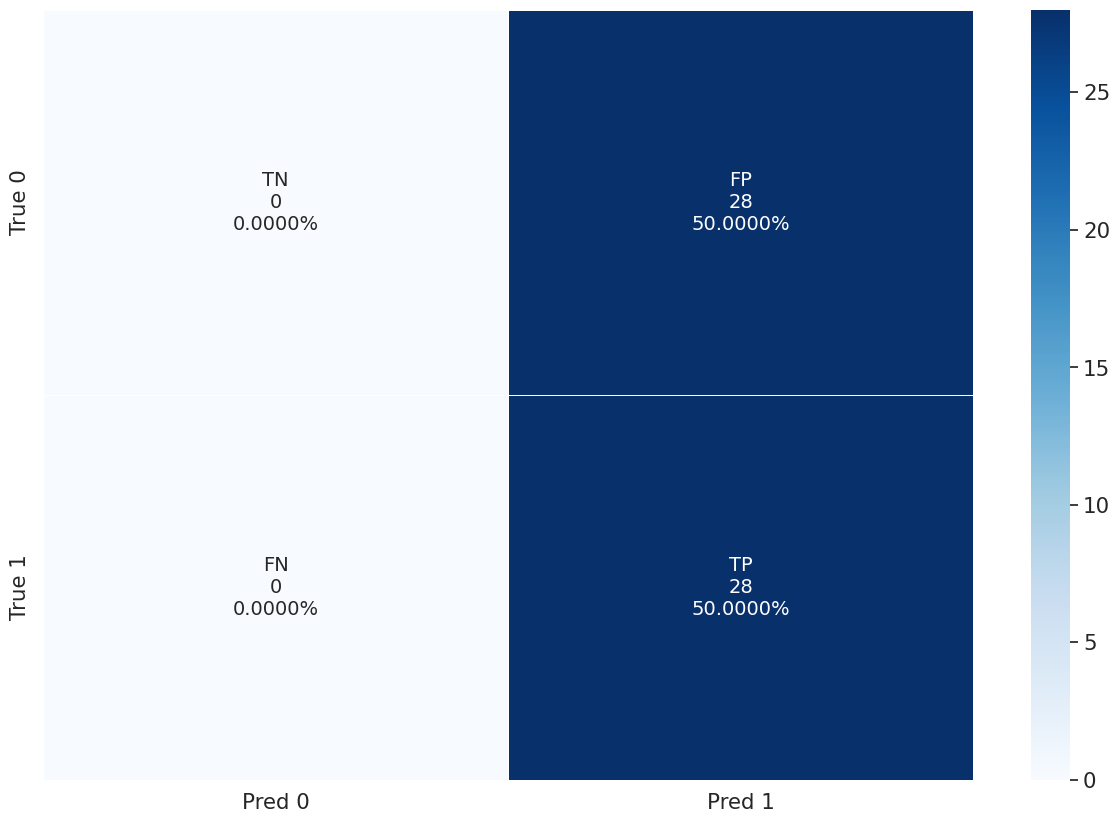

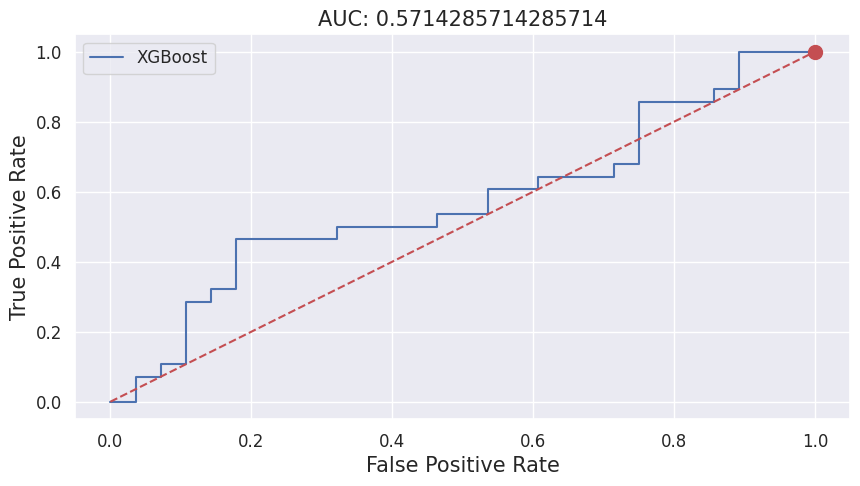

,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,XGBoost,Train set,1510,755,115,640,0,0.5412,1.0000,0.1523,0.7023,0.5762,0.5762,0.8628
1,XGBoost,Test set,56,28,0,28,0,0.5000,1.0000,0.0000,0.6667,0.5000,0.5000,0.5714
2,XGBoost,Entire population,1566,783,115,668,0,0.5396,1.0000,0.1469,0.7010,0.5734,0.5734,0.8486



   Modeling Completed. Summary of Performance (classification)


,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
0,XGBoost,Train set,1510,755,115,640,0,0.541219,1.000000,0.152318,0.702326,0.576159,0.576159,0.862803


,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
1,XGBoost,Test set,56,28,0,28,0,0.500000,1.000000,0.000000,0.666667,0.500000,0.500000,0.571429


,Algorithm,Dataset,N,True Positive,True Negative,False Positive,False Negative,Precision,Recall,Specificity,F1-score,Accuracy,Balanced Accuracy,AUC
2,XGBoost,Entire population,1566,783,115,668,0,0.539628,1.000000,0.146871,0.700985,0.573436,0.573436,0.848637


In [50]:
# Setting
algorithm_list = [best_algo]
params = best_params
TUNE_TRIALS = None
# df_domain_rename = pd.read_excel(os.path.join(FOLDER_GDM, '[Rename_20251228].xlsx'), sheet_name='Features_SI')
# df_domain_rename = {i[0]:i[1] for i in df_domain_rename[['변수설명(한글)', '변수설명(영어)']].values}
# if LANGUAGE == 'kr':
#     X_selected = [col for col in X_colname if col in list(df_domain_rename.keys())]
# else:
#     X_selected = [df_rename[col] for col in X_colname if col in list(df_domain_rename.keys())]

# ML 실행
results_SHAP, scores_SHAP = modeling_ML(
    algos=algorithm_list,
    X_train=X_train, Y_train=Y_train, X_test=X_test, Y_test=Y_test,
    X_colname=X_colname, 
    scaler_dict=scaler,
    params=params, # 특정 알고리즘
    tune_trials=TUNE_TRIALS, # 최적화 여부
    cv_splits=CV_SPLITS,
    tune_metric=TUNE_METRIC,
    shap=SHAP, 
    X_selected=None, # shap에서만 작동
    interaction=INTERACTION,
    interaction_samples=INTERACTION_SAMPLES, 
    X_top_display=X_TOP_DISPLAY-20, 
    label_list=LABEL_LIST,
)

# Group Analysis


★★★ Subgroup Performance (Fairness) Evaluation: [phase] ★★★
▶ [Info] 'phase' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다. (Phase2)
▶ [Info] 'phase' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다. (Phase3)
▶ [Info] 'phase' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다. (Phase4)


,Subgroup Target,Group Name,N,Precision,Recall,Specificity,F1-score,Accuracy,AUC
0,phase,Phase4,56,0.5000,1.0000,0.0000,0.6667,0.5000,0.5714



★★★ Subgroup Analysis Pipeline: 기준 변수 [phase] ★★★
▶ Loading existing SHAP values: ./Model/shap_values_XGBoost_20260517_230127.pkl



################################################################################
🚀 실행 중인 데이터셋: [ Train Set ]
################################################################################

------------------------------------------------------------
### [Train Total] - Full Sample Rank & Direction Calculation ###
------------------------------------------------------------
Feature Contribution Direction...


100%|██████████| 81/81 [00:00<00:00, 106.33it/s]



------------------------------------------------------------
### [phase] - Phase2 Group Analysis (Train Set) ###
------------------------------------------------------------
▶ [Info] 'phase' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Train: 572명

[Phase2] 1. Explanation Visualization (Train)
Total Explanation (Beeswarm + Importance Bar)...


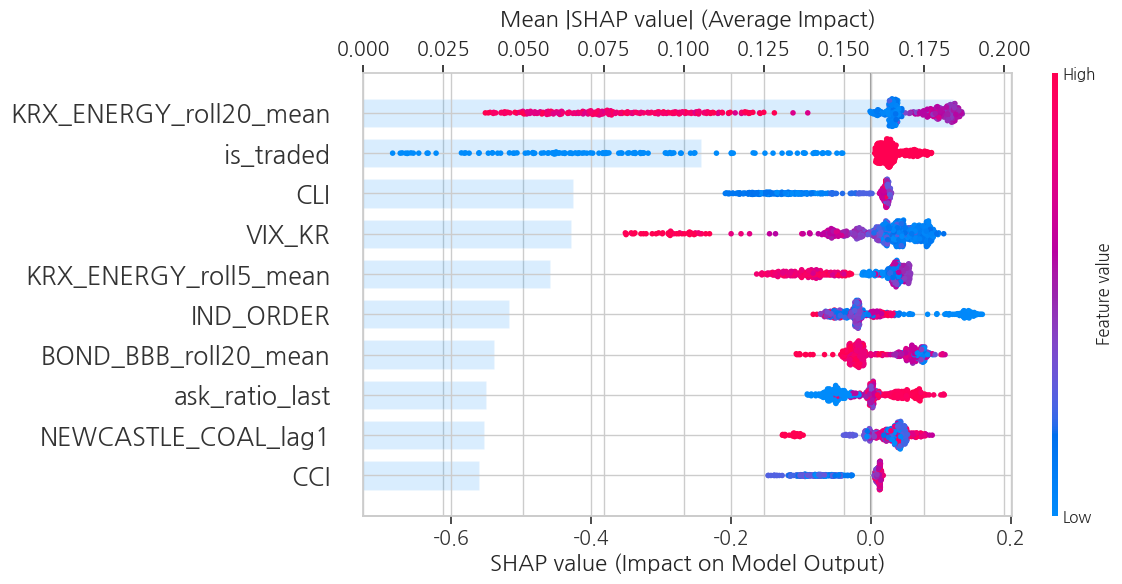

Feature Total Contribution...
Feature Contribution Direction...


100%|██████████| 81/81 [00:00<00:00, 102.70it/s]


Feature Contribution Direction...


100%|██████████| 81/81 [00:00<00:00, 102.70it/s]



------------------------------------------------------------
### [phase] - Phase3 Group Analysis (Train Set) ###
------------------------------------------------------------
▶ [Info] 'phase' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Train: 938명

[Phase3] 1. Explanation Visualization (Train)
Total Explanation (Beeswarm + Importance Bar)...


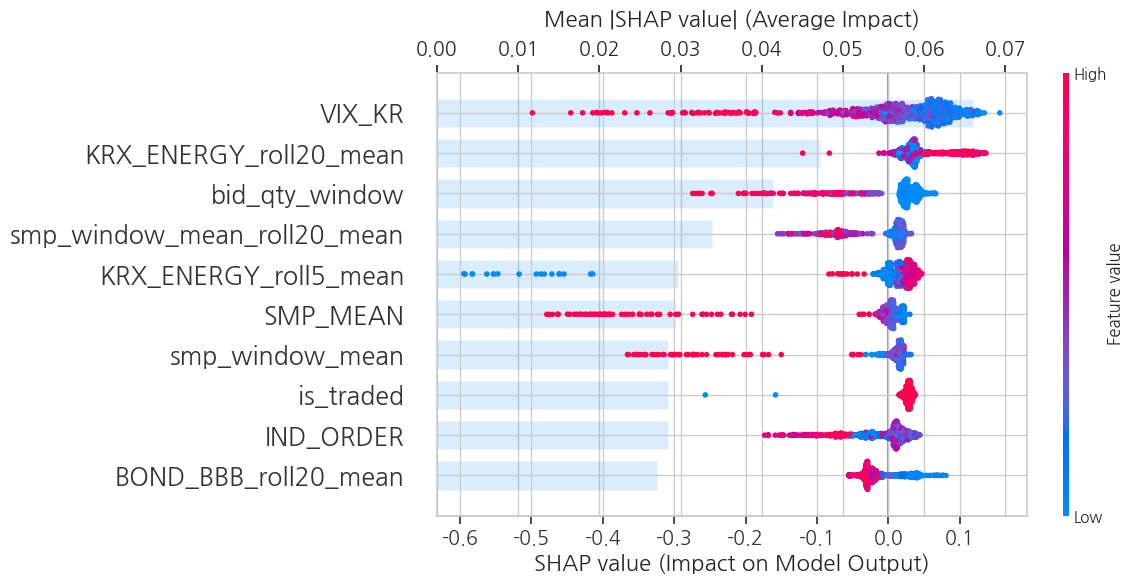

Feature Total Contribution...
Feature Contribution Direction...


100%|██████████| 81/81 [00:00<00:00, 103.37it/s]


Feature Contribution Direction...


100%|██████████| 81/81 [00:00<00:00, 97.88it/s] 


------------------------------------------------------------
### [phase] - Phase4 Group Analysis (Train Set) ###
------------------------------------------------------------
▶ [Info] 'phase' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Train: 0명

### Group Rank & Direction Master Table (Train Set, Split by: phase) ###


,Feature,Rank_Total,DirectionQR_Total,DirectionCORR_Total,Rank_Phase2,DirectionQR_Phase2,DirectionCORR_Phase2,Rank_Phase3,DirectionQR_Phase3,DirectionCORR_Phase3
0,KRX_ENERGY_roll20_mean,1,+,-,1,+,-,2,+,+
1,VIX_KR,2,-,-,4,-,-,1,-,-
2,is_traded,3,+,+,2,+,+,8,+,+
3,KRX_ENERGY_roll5_mean,4,+,-,5,+,-,5,+,+
4,CLI,5,-,+,3,+,+,15,-,-
5,IND_ORDER,6,-,-,6,+,-,9,-,-
6,bid_qty_window,7,-,-,20,-,-,3,-,-
7,BOND_BBB_roll20_mean,8,-,-,7,-,-,10,-,-
8,SMP_MEAN,9,+,-,11,+,+,6,+,-
9,USD_CNY,10,-,-,12,+,+,11,-,-



💡 [phase] 기준 하위 집단 간 방향성 이견(Discordance) 리포트 (Train Set)

▶ Correlation (CORR) 기준 엇갈리는 변수 (29개):
  - KRX_ENERGY_roll20_mean
  - KRX_ENERGY_roll5_mean
  - CLI
  - SMP_MEAN
  - USD_CNY
  - smp_window_mean_roll20_mean
  - smp_window_mean
  - CCI
  - USD
  - WTI
  - KRX_ENERGY
  - CPI
  - IIP_STEEL
  - Brent
  - GDP
  - Oman_roll5_mean
  - NEWCASTLE_COAL_roll5_mean
  - Oman_roll20_mean
  - BSI_P
  - Dubai
  - KRX_IRON
  - Oman
  - PPI
  - CAP_UTIL
  - FV_KAU19
  - ask_ratio_last_known
  - FV_KAU23
  - auction_window5
  - auction_window7
▶ Quantile Regression (QR) 기준 엇갈리는 변수 (31개):
  - CLI
  - IND_ORDER
  - USD_CNY
  - BSI_E
  - Oman_lag1
  - ask_ratio_last
  - CCI
  - KRX_ENG
  - ta_avg_window_mean
  - HH_GAS
  - BOND_BBB_roll5_mean
  - WTI
  - KRX_ENERGY
  - smp_window_mean_roll5_mean
  - CPI
  - BOND_3Y
  - Brent
  - ta_avg_dev_abs
  - IIP_MFG
  - NEWCASTLE_COAL_roll5_mean
  - smp_window_mean_lag1
  - ta_avg_dev_window_mean
  - CREDIT_SPREAD
  - Dubai
  - NEWCASTLE_COAL_roll20_mean
  - 

100%|██████████| 81/81 [00:00<00:00, 107.20it/s]



------------------------------------------------------------
### [phase] - Phase2 Group Analysis (Test Set) ###
------------------------------------------------------------
▶ [Info] 'phase' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Test: 0명

------------------------------------------------------------
### [phase] - Phase3 Group Analysis (Test Set) ###
------------------------------------------------------------
▶ [Info] 'phase' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Test: 0명

------------------------------------------------------------
### [phase] - Phase4 Group Analysis (Test Set) ###
------------------------------------------------------------
▶ [Info] 'phase' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Test: 56명

[Phase4] 1. Explanation Visualization (Test)
Total Explanation (Beeswarm + Importance Bar)...


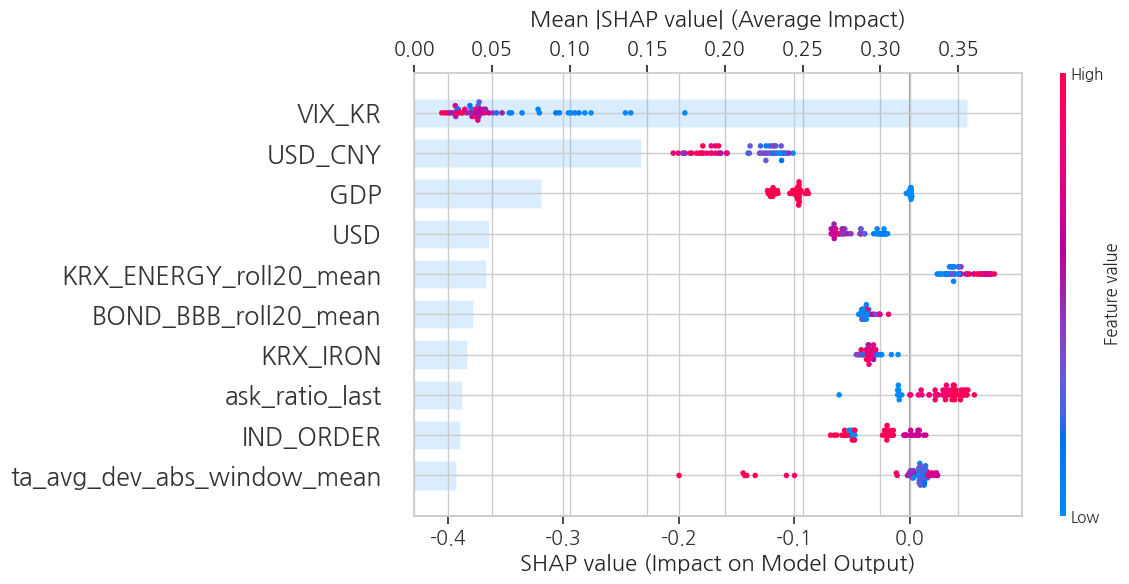

Feature Total Contribution...
Feature Contribution Direction...


100%|██████████| 81/81 [00:00<00:00, 104.73it/s]


Feature Contribution Direction...


100%|██████████| 81/81 [00:00<00:00, 105.05it/s]


### Group Rank & Direction Master Table (Test Set, Split by: phase) ###


,Feature,Rank_Total,DirectionQR_Total,DirectionCORR_Total,Rank_Phase4,DirectionQR_Phase4,DirectionCORR_Phase4
0,VIX_KR,1,-,-,1,-,-
1,USD_CNY,2,-,-,2,-,-
2,GDP,3,-,-,3,-,-
3,USD,4,-,-,4,-,-
4,KRX_ENERGY_roll20_mean,5,-,+,5,-,+
5,BOND_BBB_roll20_mean,6,+,+,6,+,+
6,KRX_IRON,7,+,-,7,+,-
7,ask_ratio_last,8,+,+,8,+,+
8,IND_ORDER,9,+,+,9,+,+
9,ta_avg_dev_abs_window_mean,10,-,-,10,-,-



💡 [phase] 기준 하위 집단 간 방향성 이견(Discordance) 리포트 (Test Set)

▶ Correlation (CORR) 기준 엇갈리는 변수 (0개):
▶ Quantile Regression (QR) 기준 엇갈리는 변수 (0개):

마스터 테이블이 저장되었습니다: /mnt/c/DataScience/[DIVE]/Project/CO2XAI/Result/FeatureImportance_MasterTable_Test_XGBoost_phase.csv

🎉 Train 및 Test 데이터셋에 대한 Subgroup Analysis가 모두 완료되었습니다.


In [68]:
# 연가구소득
target_group = 'phase'
groups = {'Phase2': 2, 'Phase3': 3, 'Phase4':4}
# key_features = [
#     'Felt unable to carry on/do anything',
#     'Satisfaction with family life',
#     'Family life causes me stress',
#     'Energy bill discount/subsidy (electricity, gas, etc.)', # 또는 'Energy bill discount/subsidy'
#     'Felt lonely',
#     'Everything felt difficult',
#     'Satisfaction with relationship with children',
#     'Satisfaction with job'
# ]
key_features=None

df_fairness = evaluation_class_GroupFairness(
    best_model=best_model,
    target_col=target_group,
    groups_dict=groups,
    X_test=X_test, Y_test=Y_test, X_colname=X_colname,
    scaler_dict=scaler
)

df_comparison = explanation_SHAP_groupcomparing(
    target_col=target_group,
    groups_dict=groups,
    X_train=X_train, X_test=X_test,
    X_colname=X_colname,
    scaler_dict=scaler,
    best_algo=best_algo,
    max_display=10,
    save_csv=True,
    target_features=key_features
)


★★★ Subgroup Performance (Fairness) Evaluation: [vintage_bucket] ★★★
▶ [Info] 'vintage_bucket' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다. (Q3b~Q4A)
▶ [Info] 'vintage_bucket' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다. (Q1)
▶ [Info] 'vintage_bucket' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다. (Q2)
▶ [Info] 'vintage_bucket' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다. (Q3)


,Subgroup Target,Group Name,N,Precision,Recall,Specificity,F1-score,Accuracy,AUC
0,vintage_bucket,Q1,46,0.5000,1.0000,0.0000,0.6667,0.5000,0.5709
1,vintage_bucket,Q2,10,0.5000,1.0000,0.0000,0.6667,0.5000,0.6000



★★★ Subgroup Analysis Pipeline: 기준 변수 [vintage_bucket] ★★★
▶ Loading existing SHAP values: ./Model/shap_values_XGBoost_20260517_230127.pkl



################################################################################
🚀 실행 중인 데이터셋: [ Train Set ]
################################################################################

------------------------------------------------------------
### [Train Total] - Full Sample Rank & Direction Calculation ###
------------------------------------------------------------
Feature Contribution Direction...


100%|██████████| 81/81 [00:00<00:00, 102.86it/s]



------------------------------------------------------------
### [vintage_bucket] - Q3b~Q4A Group Analysis (Train Set) ###
------------------------------------------------------------
▶ [Info] 'vintage_bucket' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Train: 449명

[Q3b~Q4A] 1. Explanation Visualization (Train)
Total Explanation (Beeswarm + Importance Bar)...


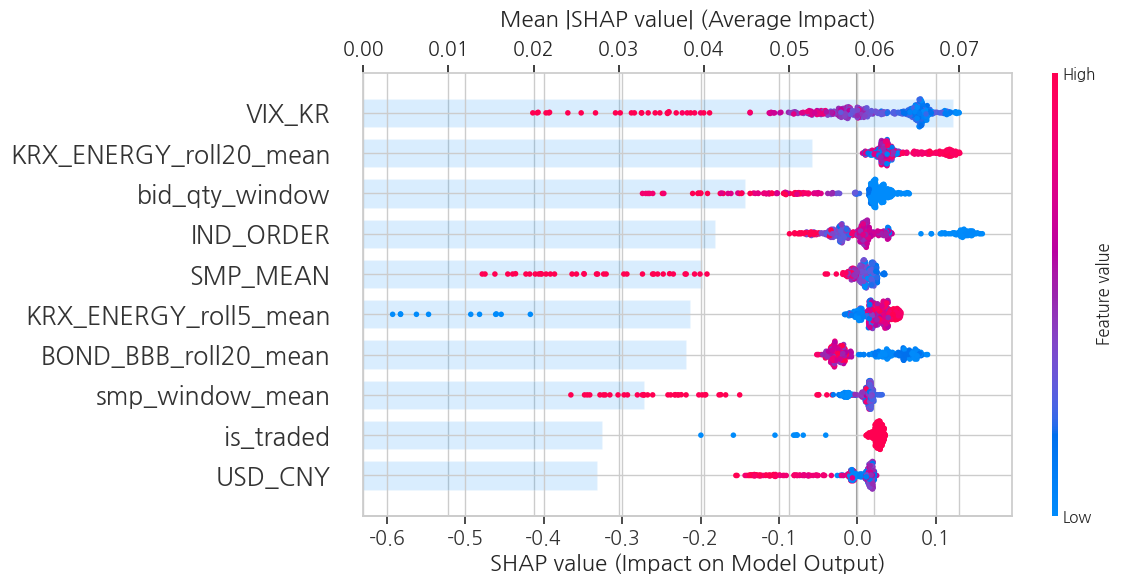

Feature Total Contribution...
Feature Contribution Direction...


100%|██████████| 81/81 [00:00<00:00, 102.97it/s]


Feature Contribution Direction...


100%|██████████| 81/81 [00:00<00:00, 101.27it/s]



------------------------------------------------------------
### [vintage_bucket] - Q1 Group Analysis (Train Set) ###
------------------------------------------------------------
▶ [Info] 'vintage_bucket' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Train: 490명

[Q1] 1. Explanation Visualization (Train)
Total Explanation (Beeswarm + Importance Bar)...


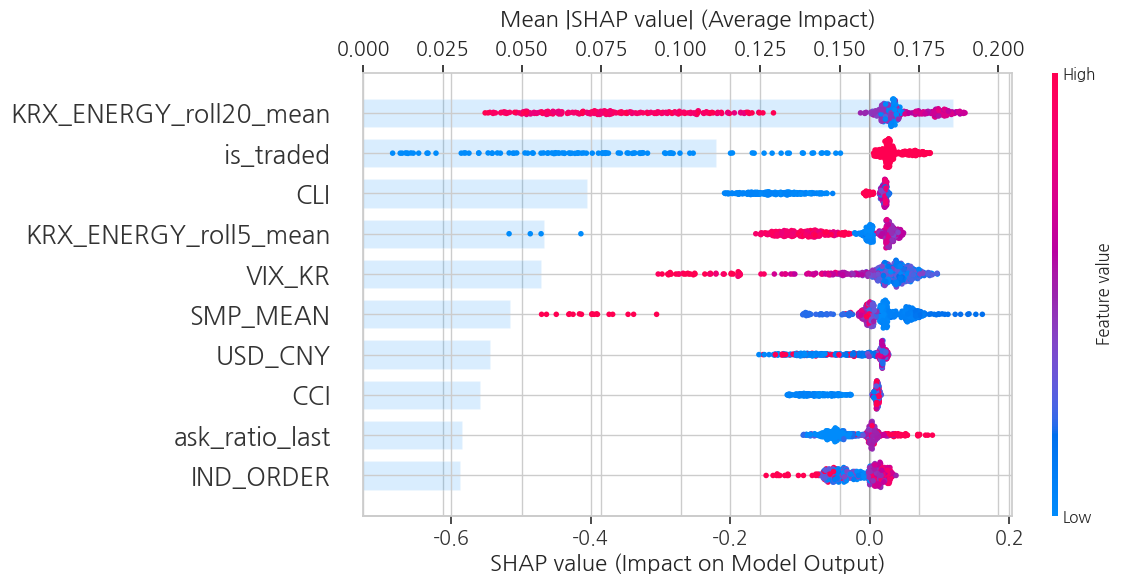

Feature Total Contribution...
Feature Contribution Direction...


100%|██████████| 81/81 [00:00<00:00, 101.43it/s]


Feature Contribution Direction...


100%|██████████| 81/81 [00:00<00:00, 102.08it/s]



------------------------------------------------------------
### [vintage_bucket] - Q2 Group Analysis (Train Set) ###
------------------------------------------------------------
▶ [Info] 'vintage_bucket' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Train: 341명

[Q2] 1. Explanation Visualization (Train)
Total Explanation (Beeswarm + Importance Bar)...


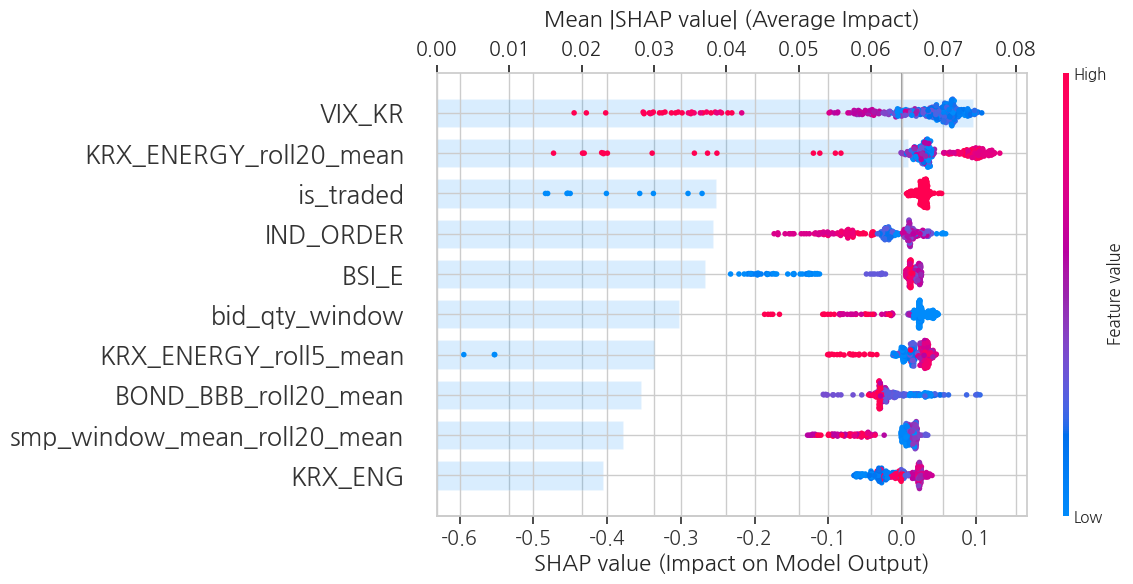

Feature Total Contribution...
Feature Contribution Direction...


100%|██████████| 81/81 [00:00<00:00, 104.20it/s]


Feature Contribution Direction...


100%|██████████| 81/81 [00:00<00:00, 101.33it/s]



------------------------------------------------------------
### [vintage_bucket] - Q3 Group Analysis (Train Set) ###
------------------------------------------------------------
▶ [Info] 'vintage_bucket' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Train: 230명

[Q3] 1. Explanation Visualization (Train)
Total Explanation (Beeswarm + Importance Bar)...


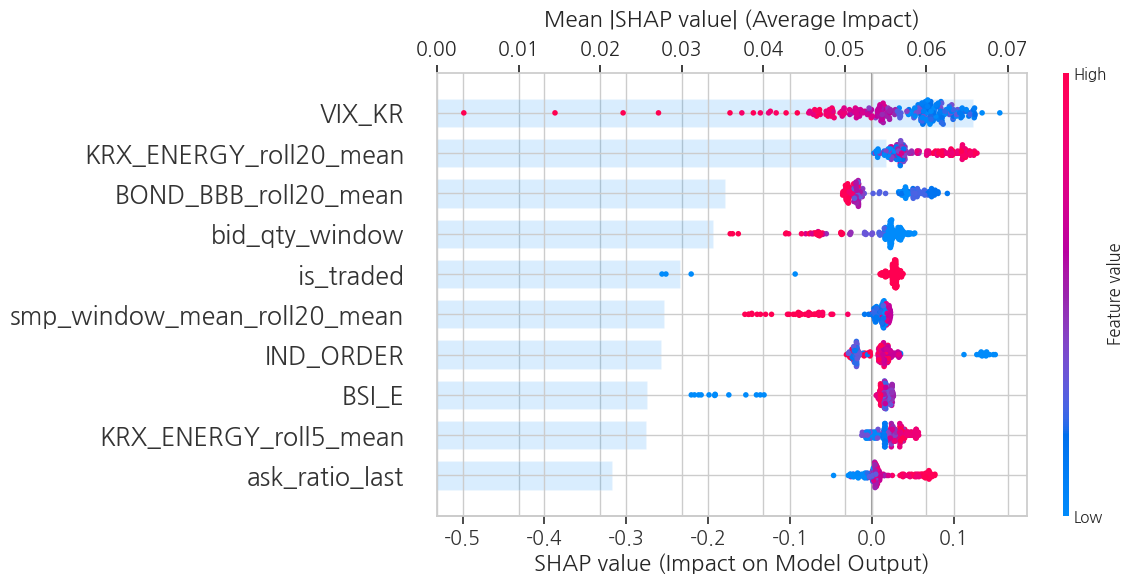

Feature Total Contribution...
Feature Contribution Direction...


100%|██████████| 81/81 [00:00<00:00, 100.35it/s]


Feature Contribution Direction...


100%|██████████| 81/81 [00:00<00:00, 105.35it/s]


### Group Rank & Direction Master Table (Train Set, Split by: vintage_bucket) ###


,Feature,Rank_Total,DirectionQR_Total,DirectionCORR_Total,Rank_Q3b~Q4A,DirectionQR_Q3b~Q4A,DirectionCORR_Q3b~Q4A,Rank_Q1,DirectionQR_Q1,DirectionCORR_Q1,Rank_Q2,DirectionQR_Q2,DirectionCORR_Q2,Rank_Q3,DirectionQR_Q3,DirectionCORR_Q3
0,KRX_ENERGY_roll20_mean,1,+,-,2,+,+,1,+,-,2,-,-,2,+,+
1,VIX_KR,2,-,-,1,-,-,5,-,-,1,-,-,1,-,-
2,is_traded,3,+,+,9,+,+,2,+,+,3,+,+,5,+,+
3,KRX_ENERGY_roll5_mean,4,+,-,6,+,+,4,-,-,7,+,+,9,+,+
4,CLI,5,-,+,15,-,-,3,+,+,13,-,+,12,-,-
5,IND_ORDER,6,-,-,4,-,-,10,+,+,4,-,-,7,-,-
6,bid_qty_window,7,-,-,3,-,-,17,-,-,6,-,-,4,-,-
7,BOND_BBB_roll20_mean,8,-,-,7,-,-,14,-,-,8,-,-,3,+,-
8,SMP_MEAN,9,+,-,5,-,-,6,+,-,29,+,-,35,-,-
9,USD_CNY,10,-,-,10,-,-,7,+,+,12,+,-,16,+,-



💡 [vintage_bucket] 기준 하위 집단 간 방향성 이견(Discordance) 리포트 (Train Set)

▶ Correlation (CORR) 기준 엇갈리는 변수 (33개):
  - KRX_ENERGY_roll20_mean
  - KRX_ENERGY_roll5_mean
  - CLI
  - IND_ORDER
  - USD_CNY
  - smp_window_mean
  - BSI_E
  - CCI
  - ta_avg_window_mean
  - USD
  - NEWCASTLE_COAL
  - ta_avg
  - WTI
  - CPI
  - IIP_STEEL
  - Brent
  - ta_avg_dev_abs
  - GDP
  - Oman_roll5_mean
  - NEWCASTLE_COAL_roll5_mean
  - BSI_P
  - ta_avg_dev_window_mean
  - ta_avg_dev
  - Dubai
  - KRX_IRON
  - IIP_CHEM
  - Oman
  - PPI
  - CAP_UTIL
  - ask_ratio_last_known
  - FV_KAU23
  - auction_window5
  - auction_window7
▶ Quantile Regression (QR) 기준 엇갈리는 변수 (48개):
  - KRX_ENERGY_roll20_mean
  - KRX_ENERGY_roll5_mean
  - CLI
  - IND_ORDER
  - BOND_BBB_roll20_mean
  - SMP_MEAN
  - USD_CNY
  - smp_window_mean_roll20_mean
  - smp_window_mean
  - NEWCASTLE_COAL_lag1
  - CCI
  - KRX_ENG
  - ta_avg_window_mean
  - USD
  - KRX_CEMENT
  - NEWCASTLE_COAL
  - BOND_BBB_roll5_mean
  - ta_avg
  - WTI
  - KRX_ENERGY
  - s

100%|██████████| 81/81 [00:00<00:00, 107.71it/s]



------------------------------------------------------------
### [vintage_bucket] - Q3b~Q4A Group Analysis (Test Set) ###
------------------------------------------------------------
▶ [Info] 'vintage_bucket' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Test: 0명

------------------------------------------------------------
### [vintage_bucket] - Q1 Group Analysis (Test Set) ###
------------------------------------------------------------
▶ [Info] 'vintage_bucket' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Test: 46명

[Q1] 1. Explanation Visualization (Test)
Total Explanation (Beeswarm + Importance Bar)...


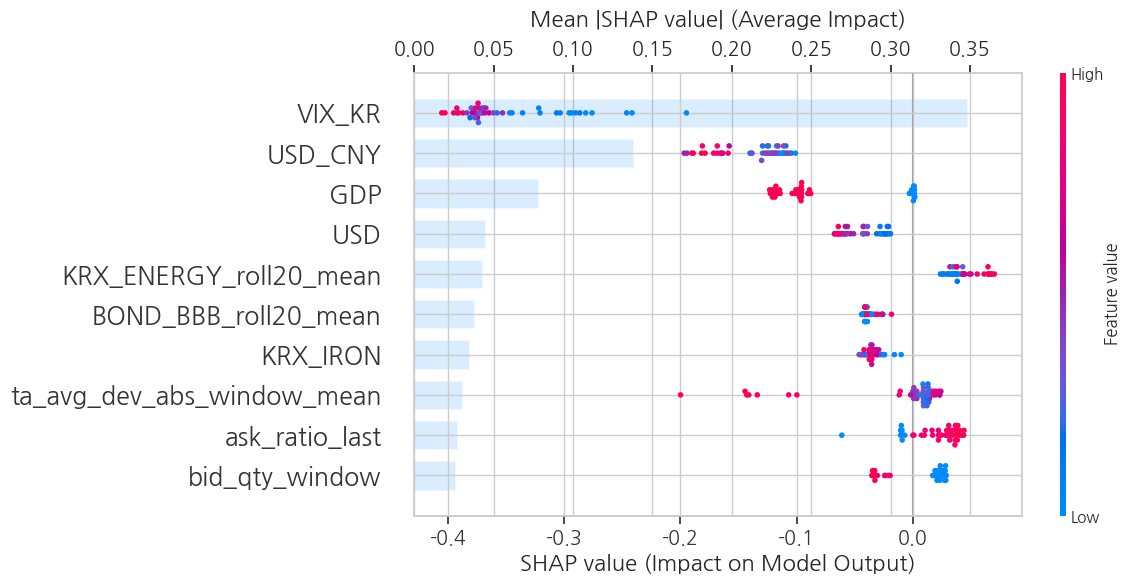

Feature Total Contribution...
Feature Contribution Direction...


100%|██████████| 81/81 [00:00<00:00, 113.45it/s]


Feature Contribution Direction...


100%|██████████| 81/81 [00:00<00:00, 113.17it/s]



------------------------------------------------------------
### [vintage_bucket] - Q2 Group Analysis (Test Set) ###
------------------------------------------------------------
▶ [Info] 'vintage_bucket' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Test: 10명

[Q2] 1. Explanation Visualization (Test)
Total Explanation (Beeswarm + Importance Bar)...


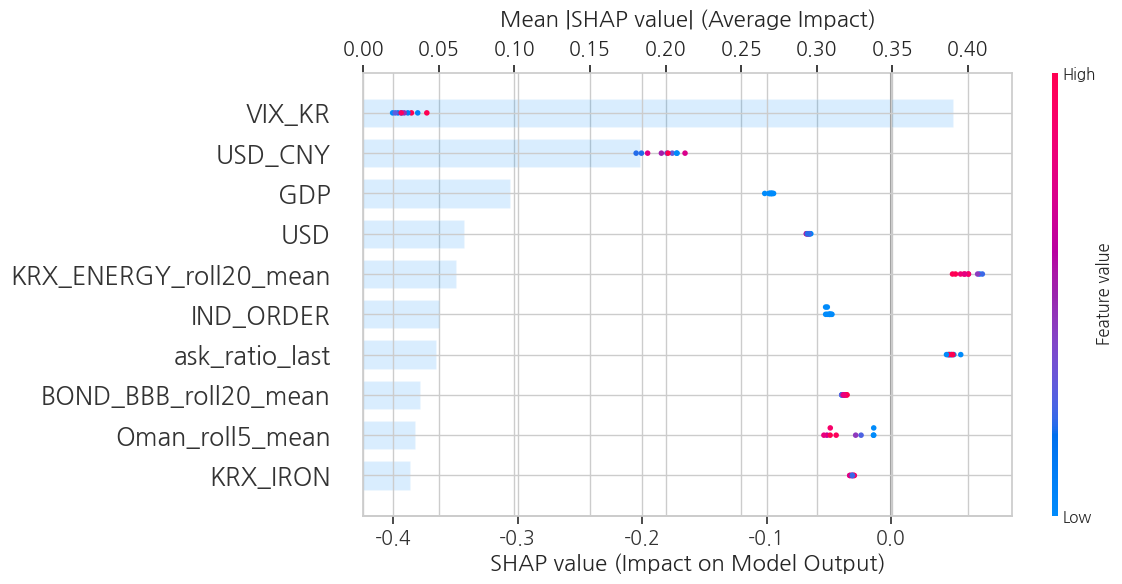

Feature Total Contribution...
Feature Contribution Direction...


100%|██████████| 81/81 [00:00<00:00, 119.07it/s]


Feature Contribution Direction...


100%|██████████| 81/81 [00:00<00:00, 119.18it/s]


------------------------------------------------------------
### [vintage_bucket] - Q3 Group Analysis (Test Set) ###
------------------------------------------------------------
▶ [Info] 'vintage_bucket' 변수를 scaler_dict를 통해 원본 스케일로 복원하여 조건을 판별합니다.
* 샘플 수 - Test: 0명

### Group Rank & Direction Master Table (Test Set, Split by: vintage_bucket) ###


,Feature,Rank_Total,DirectionQR_Total,DirectionCORR_Total,Rank_Q1,DirectionQR_Q1,DirectionCORR_Q1,Rank_Q2,DirectionQR_Q2,DirectionCORR_Q2
0,VIX_KR,1,-,-,1,-,-,1,+,+
1,USD_CNY,2,-,-,2,+,-,2,+,+
2,GDP,3,-,-,3,-,-,3,+,+
3,USD,4,-,-,4,-,-,4,+,-
4,KRX_ENERGY_roll20_mean,5,-,+,5,+,+,5,+,-
5,BOND_BBB_roll20_mean,6,+,+,6,-,+,8,+,+
6,KRX_IRON,7,+,-,7,-,-,10,+,-
7,ask_ratio_last,8,+,+,9,+,+,7,-,-
8,IND_ORDER,9,+,+,13,-,-,6,+,-
9,ta_avg_dev_abs_window_mean,10,-,-,8,-,-,30,+,+



💡 [vintage_bucket] 기준 하위 집단 간 방향성 이견(Discordance) 리포트 (Test Set)

▶ Correlation (CORR) 기준 엇갈리는 변수 (25개):
  - VIX_KR
  - USD_CNY
  - GDP
  - KRX_ENERGY_roll20_mean
  - ask_ratio_last
  - ta_avg_dev_abs_window_mean
  - ta_avg_dev_abs
  - smp_window_mean
  - Oman_lag1
  - smp_window_mean_roll20_mean
  - BOND_BBB_roll5_mean
  - NEWCASTLE_COAL_lag1
  - NEWCASTLE_COAL
  - KRX_ENERGY_lag1
  - ta_avg_dev_window_mean
  - KRX_SEMICON
  - CREDIT_SPREAD
  - NEWCASTLE_COAL_roll5_mean
  - EXPORT
  - BOND_BBB_lag1
  - CPI
  - CCI
  - BOND_BBB
  - CAP_UTIL
  - vintage_bucket
▶ Quantile Regression (QR) 기준 엇갈리는 변수 (39개):
  - VIX_KR
  - GDP
  - USD
  - BOND_BBB_roll20_mean
  - KRX_IRON
  - ask_ratio_last
  - IND_ORDER
  - ta_avg_dev_abs_window_mean
  - PPI
  - HH_GAS
  - smp_window_mean
  - Oman_roll5_mean
  - BSI_E
  - Oman_lag1
  - KRX_ENERGY_roll5_mean
  - ta_avg
  - smp_window_mean_roll5_mean
  - SMP_MEAN
  - ta_avg_dev_abs_window_max
  - NEWCASTLE_COAL_lag1
  - KRX_ENG
  - Brent
  - WTI
  - Oman_ro

In [70]:
# 연가구소득
target_group = 'vintage_bucket'
groups = {'Q3b~Q4A': 1, 'Q1': 2, 'Q2':3, 'Q3':4}
# key_features = [
#     'Felt unable to carry on/do anything',
#     'Satisfaction with family life',
#     'Family life causes me stress',
#     'Energy bill discount/subsidy (electricity, gas, etc.)', # 또는 'Energy bill discount/subsidy'
#     'Felt lonely',
#     'Everything felt difficult',
#     'Satisfaction with relationship with children',
#     'Satisfaction with job'
# ]
key_features=None

df_fairness = evaluation_class_GroupFairness(
    best_model=best_model,
    target_col=target_group,
    groups_dict=groups,
    X_test=X_test, Y_test=Y_test, X_colname=X_colname,
    scaler_dict=scaler
)

df_comparison = explanation_SHAP_groupcomparing(
    target_col=target_group,
    groups_dict=groups,
    X_train=X_train, X_test=X_test,
    X_colname=X_colname,
    scaler_dict=scaler,
    best_algo=best_algo,
    max_display=10,
    save_csv=True,
    target_features=key_features
)